<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_GaN_111_4D_STEM_with_CuPy_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# GaN [111] 4D STEM and multislice electron ptychography

**CuPy simulation, scan adjacency, dose inference, and interactive K3D point clouds**

This notebook constructs a cubic zincblende GaN single crystal and directs a 200 keV electron probe along its [111] axis. A dense diffraction pattern is calculated at each transverse probe position, giving two scan coordinates and two detector coordinates. The initial configuration contains 288 atoms in a periodic box approximately 19.18 A by 22.14 A by 7.83 A, sampled with up to 32 by 32 probe positions and a 288 by 288 detector grid.

**Crystal assumption.** The calculation uses zincblende GaN with an adjustable lattice parameter of 4.52 A. Wurtzite GaN requires its own lattice and crystallographic direction conversion; changing a label alone would leave the geometry incorrect. The [111] label here always refers to the cubic basis. Ga and N share projected columns in this orientation, so their depth ordering is visible in the atomic model, with combined contributions in the projected images. [GaN structural parameters](https://www.ioffe.ru/SVA/NSM/Semicond/GaN/basic.html).

The forward model uses abTEM Lobato independent atom potentials with CuPy Fresnel propagation. Multislice phase reconstruction employs an analytic adjoint and a known probe. NetworkX supports a periodic scan graph for optional display smoothing, and Metropolis–Hastings samples incident dose from an independent simulated vacuum calibration. FFT wave fields stay dense, which preserves the diffraction physics. [abTEM potentials](https://abtem.readthedocs.io/en/main/user_guide/walkthrough/potentials.html).

The K3D thickness stack contains a separate ADF image for each simulated exit depth. These layers describe the response of specimens truncated at successive slices. They provide a forward thickness study; they carry a different interpretation from an experimentally recovered tomogram.

## Start in Colab

1. Choose an L4 GPU runtime.
2. Run the Conda initialization cell once and allow its automatic runtime restart.
3. Run the dependency cell, then continue with the remaining cells in order.
4. Inspect the printed detector coverage, overlap, numerical checks, and held out reconstruction error.

The compute budget is a 600 second target using a GPU timing pilot. Installation, plotting, browser rendering, and optional exports have separate costs. Forward acquisition finishes as a complete dataset; reconstruction stops between completed epochs. Very expensive overrides can exceed the target. The notebook prints measured progress and keeps the best completed reconstruction.

## 3. Physical model and numerical roles

The orthonormal simulation axes are defined in the cubic crystal basis as

$$
\hat{\mathbf{x}}=\frac{(1,-1,0)}{\sqrt{2}},\qquad
\hat{\mathbf{y}}=\frac{(1,1,-2)}{\sqrt{6}},\qquad
\hat{\mathbf{z}}=\frac{(1,1,1)}{\sqrt{3}}.
$$

Here the beam travels along the positive z axis. The ASE supercell transformation preserves the zincblende basis, and transverse periodic boundaries represent a repeated crystal field of view. [ASE crystal construction](https://docs.ase-lib.org/ase/build/build.html).

For slice j, the integral of electrostatic potential V over its thickness defines the projected potential Vj and phase shift phi_j,

$$
V_j(x,y)=\int_{z_j}^{z_{j+1}} V(x,y,z)\,dz,
\qquad \phi_j(x,y)=\sigma(E)V_j(x,y).
$$

Vj is expressed in volt angstroms and the relativistic interaction constant sigma in radians per volt angstrom. The implementation uses abTEM's energy conversion functions for the electron wavelength and interaction constant. Each atom's infinite projected potential is assigned to a slice, providing a standard projected atom multislice discretization.

The paraxial propagation step is

$$
\psi_{j+1}=\mathcal{F}^{-1}\!\left[
B(\mathbf{q})e^{-i\pi\lambda\Delta z_j|\mathbf{q}|^2}
\mathcal{F}\!\left(e^{i\phi_j}\psi_j\right)\right].
$$

The unitary transverse transform is denoted by F; reciprocal coordinates q have units of inverse angstroms, lambda is the relativistic wavelength, and B is a circular antialias aperture. Its cutoff retains two thirds of the smallest Cartesian Nyquist frequency. The detector's outer ADF angle must lie inside this usable region, and the code checks that condition. [abTEM multislice walkthrough](https://abtem.readthedocs.io/en/main/user_guide/walkthrough/multislice.html).

At scan position R, the normalized probe is translated by its Fourier phase ramp. For D incident electrons and F thermal configurations, the mean detector counts are

$$
\mu_{\mathbf R}(\mathbf q)
=\frac{D}{F}\sum_{f=1}^{F}
\left|\mathcal F\{\psi_{\mathrm{exit},\mathbf R,f}\}(\mathbf q)\right|^2,
\qquad C_{\mathbf R}(\mathbf q)\sim\operatorname{Poisson}(\mu_{\mathbf R}(\mathbf q)).
$$

The array C stores counts. ADF integrates the counts over an annulus defined by inner and outer scattering angles, using the small angle relation

$$
\theta\simeq\lambda|\mathbf q|,
\qquad
A(\mathbf R)=\frac{1}{\widehat D}
\sum_{\theta_{\mathrm{in}}\leq\theta<\theta_{\mathrm{out}}} C_{\mathbf R}(\mathbf q).
$$

A is the measured fraction of incident dose. A separate expected ADF thickness stack uses noiseless forward probabilities; it avoids suggesting that an experiment measures every internal exit plane simultaneously.

| Component | Calculation | Purpose and boundary |
|---|---|---|
| ASE | Atomic positions and oriented cell | Preserves cubic [111] geometry and chemical basis |
| abTEM | Lobato independent atom slice potentials | Supplies element specific scattering; bonding charge redistribution lies outside the model |
| CuPy tensors and FFTs | Batched multislice wave propagation | Produces dense diffraction at every scan position |
| CuPy adjoint | Multislice phase optimization | Fits coherent diffraction using a known probe and slice count |
| NetworkX adjacency | Periodic nearest neighbor scan graph | Describes nearby scan samples for display filtering |
| CuPy CSR or dense operator | Bounded graph smoothing | Changes display contrast; raw counts always drive reconstruction |
| Metropolis–Hastings | Scalar dose posterior | Uses GPU reduced calibration counts, then samples a scalar chain on the CPU |
| Adaptive controller | Timing and memory estimates | Adjusts batches, scan count within a sampling target, and completed epochs |
| K3D | Point rendering | Shows atomic positions, expected ADF exit layers, and a projected phase surface |

The reconstruction minimizes a Fourier amplitude objective with phase parameters for every slice,

$$
\mathcal L(\{\phi_j\})=\frac{1}{2N}
\sum_{\mathbf R,\mathbf q}
\left(|\Psi_{\mathbf R}(\mathbf q;\{\phi_j\})|
-\sqrt{C_{\mathbf R}(\mathbf q)/\widehat D}\right)^2.
$$

N counts the scan positions in the objective. Reverse propagation yields the derivative with respect to each slice phase; the code verifies this derivative against a finite difference. Minibatch updates use an illumination preconditioner and remove an unobservable constant phase from each slice. A held out subset tracks prediction error and controls learning rate reduction and early stopping. This is a known probe, phase only multislice inverse problem, with a Fourier amplitude loss that can acquire bias in the low count regime.

For vacuum calibration, K independent exposures produce a total S. Under a Gamma prior with shape a and rate b, the dose posterior is

$$
D\mid S,K\sim\operatorname{Gamma}(S+a,K+b).
$$

The notebook samples the log dose and includes its change of variables Jacobian in the acceptance ratio. An exact Gamma density provides a benchmark for the Markov chain. The closed form posterior also allows direct inference in production work; the chain is retained here to give the requested Metropolis–Hastings component a testable statistical role.

## 4. Controls and GPU functions

| Control | Initial value | Interpretation |
|---|---:|---|
| `ENERGY_EV` | 200000 | Electron kinetic energy |
| `LATTICE_A` | 4.52 | Cubic lattice parameter in angstroms |
| `REPEATS` | (3, 2, 1) | Repetitions of the oriented orthogonal cell |
| `GRID` | 288 | Transverse wave and detector samples along each axis |
| `SLICE_A` | 1.0 | Maximum projected atom slice thickness in angstroms |
| `CONVERGENCE_MRAD` | 22 | Probe aperture semiangle |
| `ADF_MRAD` | (40, 100) | ADF annulus in milliradians |
| `SCAN_SIDE` | 32 | Maximum scan count along each transverse direction |
| `ELECTRONS_PER_POSITION` | 200000 | Incident electrons for each exposure |
| `PHONON_CONFIGS` | 1 | Number of frozen configurations averaged in intensity |
| `THERMAL_RMS_A` | Ga 0, N 0 | Per Cartesian component displacement standard deviation |
| `TIME_BUDGET_S` | 600 | Soft computation target |
| `AUTO_ADAPT` | True | Enables memory and time aware execution |
| `GPU_MEMORY_FRACTION` | 0.20 | Fraction used for conservative memory checks |
| `MAX_HOST_DATA_GIB` | 1.0 | Maximum host footprint targeted for the diffraction tensor |
| `BATCH_OVERRIDE` | 4 | Probe count per GPU batch |
| `MAX_EPOCHS` | 12 | Upper bound on reconstruction passes |
| `PHASE_STEP` | 0.7 | Reconstruction step factor divided by slice count |
| `RUN_NUMERICAL_CHECKS` | False | Enables derivative and half slice convergence checks |
| `SPARSE_MODE` | auto | CSR selection for the scan graph |
| `GRAPH_MEMORY_MIB` | 256 | Graph operator memory limit |
| `K3D_UPSAMPLE` | 4 | Display interpolation factor, set in the final plotting cell |
| `K3D_MAX_POINTS` | 500000 | Point limit for the ADF thickness viewer |

The zero displacement default creates a coherent elastic reference with matched forward and inverse models. To explore thermal diffuse scattering, set a finite per species RMS displacement and increase `PHONON_CONFIGS`, then perform a configuration count convergence study. Illustrative 0.06 A displacements have no assigned temperature in this notebook. Averaged thermal data introduce a mismatch to this coherent inverse model; a mixed state reconstruction would be the next extension.

Grid refinement changes detector coverage and potential sampling. Increasing the K3D interpolation factor changes visual point density alone. The scan spacing is reported together with the adjacent probe overlap so sampling quality can be inspected directly.


## Colab runtime

Select an NVIDIA L4 GPU runtime and start from a fresh session. Run the Conda initialization cell first. The session restarts automatically. After reconnecting, run the scientific stack cell, then use **Runtime → Restart session** once before continuing to the verification cell.


In [1]:
"""Initialize Conda in Google Colab."""

import subprocess
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "-q", "install", "condacolab==0.1.13"],
    check=True,
)

import condacolab

condacolab.install()



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


### Scientific stack

After the Conda restart finishes, run the next cell once. It installs the numerical stack from conda-forge in one transaction. K3D 2.18.1 is then installed without dependency resolution so the compiled numerical packages stay under Conda control.


In [2]:
"""Install the GaN STEM scientific stack."""

import shutil
import subprocess

solver = shutil.which("mamba") or shutil.which("conda")
if solver is None:
    raise RuntimeError("Conda is unavailable. Run the Conda initialization cell first.")

packages = [
    "numpy=2.4.6",
    "scipy=1.17.0",
    "pandas=2.3.3",
    "numba=0.66.0",
    "llvmlite=0.48.0",
    "numba-cuda=0.30.4",
    "cuda-version=12.8",
    "cupy=14.2.0",
    "abtem=1.0.10",
    "k3d=2.17.0",
    "ipywidgets",
    "networkx",
    "matplotlib",
]

subprocess.run(
    [
        solver,
        "install",
        "-y",
        "-c",
        "conda-forge",
        "--strict-channel-priority",
        *packages,
    ],
    check=True,
)

subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "-q",
        "install",
        "--no-deps",
        "k3d==2.18.1",
    ],
    check=True,
)

print("Scientific stack installed.")

Scientific stack installed.


### Session restart

Use **Runtime → Restart session** once now. Continue with the verification cell after the session reconnects.


In [3]:
"""Verify the CPU, CUDA, CuPy, Numba, and abTEM stack."""

from importlib.metadata import version

import abtem
import abtem.core._cuda
import cupy as cp
import numba
import numpy as np
import scipy
from numba import cuda

expected = {
    "numpy": "2.4.6",
    "scipy": "1.17.0",
    "numba": "0.66.0",
    "llvmlite": "0.48.0",
    "numba-cuda": "0.30.4",
    "cupy": "14.2.0",
    "abtem": "1.0.10",
    "k3d": "2.18.1",
}

for package, expected_version in expected.items():
    installed = version(package)
    if installed != expected_version:
        raise RuntimeError(
            f"{package}={installed}; expected {expected_version}. "
            "Restart the session and rerun this cell."
        )

if not cuda.is_available():
    raise RuntimeError("Numba CUDA cannot access the selected GPU.")


@cuda.jit
def cuda_smoke(values):
    """Apply a simple affine map on the GPU."""
    index = cuda.grid(1)
    if index < values.size:
        values[index] = 2.0 * values[index] + 1.0


host_values = np.arange(256, dtype=np.float32)
device_values = cuda.to_device(host_values)
cuda_smoke[2, 128](device_values)
cuda_result = device_values.copy_to_host()

if not np.allclose(cuda_result, 2.0 * host_values + 1.0):
    raise RuntimeError("Numba CUDA kernel verification failed.")

cupy_values = cp.arange(1_000_000, dtype=cp.float32)
cupy_total = float(cp.sum(cupy_values).item())
cp.cuda.Stream.null.synchronize()

if not np.isfinite(cupy_total) or cupy_total <= 0.0:
    raise RuntimeError("CuPy CUDA verification failed.")

properties = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = properties["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

print(f"GPU        : {gpu_name}")
print(f"NumPy      : {np.__version__}")
print(f"SciPy      : {scipy.__version__}")
print(f"Numba      : {numba.__version__}")
print(f"Numba CUDA : {version('numba-cuda')}")
print(f"CuPy       : {cp.__version__}")
print(f"abTEM      : {abtem.__version__}")
print("SCIENTIFIC STACK CHECK: PASS")


/usr/local/lib/python3.13/site-packages/dask/array/chunk_types.py:110: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  import cupy
/usr/local/lib/python3.13/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 2 will likely resu

GPU        : NVIDIA L4
NumPy      : 2.1.3
SciPy      : 1.17.0
Numba      : 0.66.0
Numba CUDA : 0.30.4
CuPy       : 14.2.0
abTEM      : 1.0.10
SCIENTIFIC STACK CHECK: PASS


In [4]:
"""Define the GaN [111] multislice model and GPU numerical functions."""

# --- Control knobs ---
ENERGY_EV = 200_000.0
LATTICE_A = 4.52
REPEATS = (3, 2, 1)
GRID = 288
SLICE_A = 1.0
CONVERGENCE_MRAD = 22.0
DEFOCUS_A = 0.0
CS_A = 0.0
ADF_MRAD = (40.0, 100.0)
BF_MRAD = (0.0, 22.0)
ELECTRONS_PER_POSITION = 200_000.0
PHONON_CONFIGS = 1
THERMAL_RMS_A = {"Ga": 0.0, "N": 0.0}
SCAN_SIDE = 32
AUTO_ADAPT = True
TIME_BUDGET_S = 600.0
GPU_MEMORY_FRACTION = 0.20
MAX_HOST_DATA_GIB = 1.0
BATCH_OVERRIDE = 4
MAX_EPOCHS = 12
MIN_EPOCHS = 3
PHASE_STEP = 0.7
EARLY_STOP_PATIENCE = 4
RUN_NUMERICAL_CHECKS = False
SPARSE_MODE = "auto"
SPARSE_THRESHOLD_NODES = 512
GRAPH_MEMORY_MIB = 256.0
GRAPH_SMOOTH_STEPS = 8
GRAPH_SMOOTH_STRENGTH = 0.10
MH_STEPS = 6000
MH_BURN = 1000
VACUUM_CALIBRATION_FRAMES = 64
SEED = 71
SAVE_4D_DATA = False
COUNTS_FILE = "GaN_111_4DSTEM_counts.dat"

import gc
import json
import time
from importlib.metadata import version
from pathlib import Path

import abtem
import cupy as cp
import matplotlib.pyplot as plt
import networkx as nx
import numba
import numpy as np
from abtem.core.energy import energy2sigma, energy2wavelength
from ase.build import bulk, make_supercell
from cupyx.scipy import sparse as gpu_sparse
from scipy.sparse import csr_matrix
from scipy.stats import gamma

plt.rcParams["figure.dpi"] = 250
plt.rcParams["savefig.dpi"] = 250
plt.rcParams["axes.grid"] = False
plt.rcParams["image.cmap"] = "magma"

rng = np.random.default_rng(SEED)
cp.random.seed(SEED)
numba.set_num_threads(2)


def fft2(array):
    """Apply a unitary transverse Fourier transform."""
    return cp.fft.fft2(array, axes=(-2, -1), norm="ortho")


def ifft2(array):
    """Apply the inverse unitary transverse Fourier transform."""
    return cp.fft.ifft2(array, axes=(-2, -1), norm="ortho")


def host(array):
    """Transfer a device array to host memory."""
    return cp.asnumpy(array)


def sync():
    """Synchronize the default CUDA stream."""
    cp.cuda.Stream.null.synchronize()


def release_gpu_cache():
    """Release unused CuPy memory-pool and FFT-plan allocations."""
    gc.collect()
    try:
        cp.fft.config.get_plan_cache().clear()
    except Exception:
        pass
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()


def report_gpu_memory(label):
    """Print current CUDA memory use in gibibytes."""
    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
    used_bytes = total_bytes - free_bytes
    print(
        f"[{label}] GPU used={used_bytes / 2**30:.2f} GiB, "
        f"free={free_bytes / 2**30:.2f} GiB",
        flush=True,
    )


def crystal_111():
    """Orient zincblende GaN with z parallel to the cubic [111] axis."""
    unit = bulk("GaN", "zincblende", a=LATTICE_A, cubic=True)
    transform = np.array([[1, -1, 0], [1, 1, -2], [1, 1, 1]])
    atoms = make_supercell(unit, transform)
    axes = np.asarray(atoms.cell)
    lengths = np.linalg.norm(axes, axis=1)
    basis = axes / lengths[:, None]

    assert np.allclose(basis @ basis.T, np.eye(3))
    assert np.linalg.det(basis) > 0

    atoms.positions = atoms.positions @ basis.T
    atoms.set_cell(np.diag(lengths), scale_atoms=False)
    atoms = atoms.repeat(REPEATS)
    atoms.positions[:, 2] += 0.137
    atoms.wrap()

    assert len(atoms) == 48 * int(np.prod(REPEATS))
    return atoms


def potential_stack(atoms, grid, dz):
    """Build Lobato IAM potential slices in V A on the CPU."""
    print(
        f"Building electrostatic potential: grid={grid}, dz={dz:.3f} A",
        flush=True,
    )

    builder = abtem.Potential(
        atoms,
        gpts=(grid, grid),
        slice_thickness=dz,
        parametrization="lobato",
        projection="infinite",
        device="cpu",
    )
    result = builder.build(max_batch=1, lazy=False)

    potential = np.asarray(
        result.array,
        dtype=np.float32,
    ).transpose(0, 2, 1)
    thickness = np.asarray(
        result.slice_thickness,
        dtype=np.float32,
    )

    print(
        f"Potential shape={potential.shape}; "
        f"host memory={potential.nbytes / 2**20:.1f} MiB",
        flush=True,
    )
    return potential.copy(), thickness


def reciprocal_grid(grid, lengths, wavelength):
    """Return FFT frequencies, angles, and a circular antialias aperture."""
    qx = cp.fft.fftfreq(grid, d=lengths[0] / grid).astype(cp.float32)
    qy = cp.fft.fftfreq(grid, d=lengths[1] / grid).astype(cp.float32)
    qxx, qyy = cp.meshgrid(qx, qy, indexing="xy")
    q2 = qxx**2 + qyy**2
    cutoff = min(grid / (3 * lengths[0]), grid / (3 * lengths[1]))
    mask = q2 < cutoff**2
    angles = 1000.0 * wavelength * cp.sqrt(q2)
    return qxx, qyy, q2, angles, mask, cutoff


def make_probe(q2, angles, wavelength):
    """Normalize a coherent aberrated aperture to one incident electron."""
    chi = (
        np.pi * wavelength * DEFOCUS_A * q2
        + 0.5 * np.pi * CS_A * wavelength**3 * q2**2
    )
    aperture = (angles <= CONVERGENCE_MRAD) * cp.exp(-1j * chi)
    norm = cp.sqrt(cp.sum(cp.abs(aperture) ** 2))
    return (aperture / norm).astype(cp.complex64)


def shifted_probes(positions, aperture, qxx, qyy):
    """Shift a periodic probe to each continuous scan position."""
    positions = cp.asarray(positions, dtype=cp.float32)
    phase = -2j * np.pi * (
        positions[:, 0, None, None] * qxx
        + positions[:, 1, None, None] * qyy
    )
    return ifft2(aperture[None] * cp.exp(phase)).astype(cp.complex64)


def propagators(thickness, wavelength, q2, mask):
    """Build Fresnel propagation factors with a two-thirds bandwidth."""
    dz = cp.asarray(thickness, dtype=cp.float32)
    phase = -1j * np.pi * wavelength * dz[:, None, None] * q2
    return (cp.exp(phase) * mask).astype(cp.complex64)


def forward(probes, phase, propagation, adf_mask=None, retain=False):
    """Propagate one probe batch through every potential slice."""
    use_double = (
        probes.dtype == cp.complex128
        or phase.dtype == cp.float64
    )
    complex_dtype = (
        cp.complex128 if use_double else cp.complex64
    )
    real_dtype = (
        cp.float64 if use_double else cp.float32
    )

    wave = probes.astype(
        complex_dtype,
        copy=True,
    )
    propagation_local = propagation.astype(
        complex_dtype,
        copy=False,
    )
    states = []
    depth = []

    for index in range(len(phase)):
        transmission = cp.exp(
            1j * phase[index]
        ).astype(complex_dtype)
        post = wave * transmission

        if retain:
            states.append(post)

        spectrum = (
            fft2(post)
            * propagation_local[index]
        )

        if adf_mask is not None:
            depth.append(
                cp.sum(
                    cp.abs(spectrum) ** 2 * adf_mask,
                    axis=(-2, -1),
                    dtype=real_dtype,
                )
            )

        wave = ifft2(spectrum).astype(
            complex_dtype
        )

    depth_array = (
        cp.stack(depth)
        if depth
        else None
    )
    return spectrum, states, depth_array


def phase_gradient(probes, phase, propagation, target):
    """Differentiate the Fourier amplitude objective by reverse propagation."""
    use_double = (
        probes.dtype == cp.complex128
        or phase.dtype == cp.float64
    )
    complex_dtype = (
        cp.complex128 if use_double else cp.complex64
    )
    real_dtype = (
        cp.float64 if use_double else cp.float32
    )
    propagation_local = propagation.astype(
        complex_dtype,
        copy=False,
    )

    spectrum, states, _ = forward(
        probes,
        phase,
        propagation_local,
        retain=True,
    )
    amplitude = cp.abs(spectrum)
    residual = amplitude - target
    loss = (
        cp.sum(
            residual**2,
            dtype=cp.float64,
        )
        / (2 * len(probes))
    )

    ratio = target / cp.maximum(
        amplitude,
        1e-12,
    )
    adjoint = ifft2(
        spectrum * (1.0 - ratio)
    ).astype(complex_dtype)

    gradients = []
    illumination = []

    for index in range(len(phase) - 1, -1, -1):
        adjoint = ifft2(
            fft2(adjoint)
            * cp.conj(
                propagation_local[index]
            )
        ).astype(complex_dtype)

        post = states[index]
        gradients.append(
            cp.sum(
                cp.imag(
                    cp.conj(post) * adjoint
                ),
                axis=0,
                dtype=real_dtype,
            )
        )
        illumination.append(
            cp.sum(
                cp.abs(post) ** 2,
                axis=0,
                dtype=real_dtype,
            )
        )

        transmission = cp.exp(
            -1j * phase[index]
        ).astype(complex_dtype)
        adjoint *= transmission

    gradient_stack = cp.stack(
        gradients[::-1]
    )
    illumination_stack = cp.stack(
        illumination[::-1]
    )
    return loss, gradient_stack, illumination_stack


def dose_mh(counts):
    """Sample dose with a log random walk and an exact Gamma reference."""
    values = np.asarray(counts, dtype=np.float64)
    total = float(values.sum())
    shape = total + 1.0
    rate = len(values) + 1e-6
    center = np.log(shape / rate)
    proposal_sd = 2.4 / np.sqrt(shape)
    log_dose = center

    trace = np.empty(MH_STEPS, dtype=np.float64)
    accepted = 0

    for step in range(MH_STEPS):
        proposal = log_dose + rng.normal(0.0, proposal_sd)
        delta = proposal - log_dose
        log_ratio = (
            shape * delta
            - rate * np.exp(log_dose) * np.expm1(delta)
        )

        if np.log(rng.random()) < min(0.0, log_ratio):
            log_dose = proposal
            accepted += 1

        trace[step] = np.exp(log_dose)

    kept = trace[MH_BURN:]
    exact_ci = gamma.ppf(
        [0.025, 0.975],
        a=shape,
        scale=1.0 / rate,
    )

    return (
        float(np.mean(kept)),
        trace,
        exact_ci,
        accepted / MH_STEPS,
    )


def graph_filter(images, scan_side):
    """Smooth scan maps with a bounded GPU graph operator for display."""
    if SPARSE_MODE not in {"auto", "on", "off"}:
        raise ValueError("SPARSE_MODE must be auto, on, or off.")

    graph = nx.grid_2d_graph(
        scan_side,
        scan_side,
        periodic=True,
    )
    nodes = [
        (iy, ix)
        for iy in range(scan_side)
        for ix in range(scan_side)
    ]
    adjacency = csr_matrix(
        nx.to_scipy_sparse_array(
            graph,
            nodelist=nodes,
            dtype=np.float32,
            format="csr",
        )
    )

    node_count = len(nodes)
    dense_bytes = node_count * node_count * 4
    csr_bytes = (
        adjacency.data.nbytes
        + adjacency.indices.nbytes
        + adjacency.indptr.nbytes
    )
    limit = GRAPH_MEMORY_MIB * 2**20

    use_sparse = SPARSE_MODE == "on" or (
        SPARSE_MODE == "auto"
        and (
            node_count >= SPARSE_THRESHOLD_NODES
            or dense_bytes > limit
        )
    )

    required_bytes = csr_bytes if use_sparse else dense_bytes
    if required_bytes > limit:
        raise MemoryError(
            "Graph allocation exceeds GRAPH_MEMORY_MIB."
        )

    if use_sparse:
        operator = gpu_sparse.csr_matrix(adjacency)
    else:
        operator = cp.asarray(adjacency.toarray())

    degree = cp.asarray(
        np.asarray(adjacency.sum(axis=1)).ravel(),
        dtype=cp.float32,
    )
    output = cp.asarray(
        images.reshape(len(images), -1).T,
        dtype=cp.float32,
    )

    for _ in range(GRAPH_SMOOTH_STEPS):
        neighbors = (operator @ output) / degree[:, None]
        output += GRAPH_SMOOTH_STRENGTH * (neighbors - output)

    result = host(output.T).reshape(images.shape)
    del operator
    del degree
    del output
    release_gpu_cache()
    return result, graph, use_sparse


## 5. Simulate and reconstruct

The diffraction tensor is stored as a disk-backed NumPy array and streamed to the GPU in small batches. The program reports detector coverage, adjacent probe overlap, CUDA memory use, retained incident flux, dose calibration, reconstruction progress, and elapsed time. Numerical derivative and half slice convergence checks are available behind `RUN_NUMERICAL_CHECKS` so the primary simulation can run with a bounded memory footprint.

Convergence of diffraction error alone provides limited information about depth accuracy from one incident beam direction. Inspect the projected phase error against the known simulated object, and treat individual reconstructed slices as an ill conditioned inverse result. The ADF K3D depth stack comes directly from forward exits, independent of any inferred slice interpretation.


In [5]:
"""Run the GaN [111] diffraction simulation and multislice reconstruction."""

start_time = time.perf_counter()

if cp.cuda.runtime.getDeviceCount() < 1:
    raise RuntimeError(
        "Select an NVIDIA GPU runtime in Colab and rerun this cell."
    )

if PHONON_CONFIGS < 1:
    raise ValueError("PHONON_CONFIGS must be at least 1.")
if GRID < 64 or SCAN_SIDE < 8:
    raise ValueError("GRID must be at least 64 and SCAN_SIDE at least 8.")
if not 0.0 < GPU_MEMORY_FRACTION < 0.8:
    raise ValueError("GPU_MEMORY_FRACTION must lie between 0 and 0.8.")
if MAX_EPOCHS < MIN_EPOCHS or MIN_EPOCHS < 1:
    raise ValueError("Require MAX_EPOCHS >= MIN_EPOCHS >= 1.")

release_gpu_cache()

properties = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = properties["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

print(f"GPU: {gpu_name}", flush=True)
print(
    {
        name: version(name)
        for name in [
            "cupy",
            "abtem",
            "ase",
            "networkx",
        ]
    },
    flush=True,
)
report_gpu_memory("initial")

print("\nStage 1/7: crystal and reciprocal grid", flush=True)

atoms = crystal_111()
lengths = np.asarray(atoms.cell.lengths(), dtype=np.float64)
wavelength = energy2wavelength(ENERGY_EV)
sigma = energy2sigma(ENERGY_EV)

qxx, qyy, q2, angles, bandwidth, cutoff = reciprocal_grid(
    GRID,
    lengths,
    wavelength,
)
cutoff_mrad = 1000.0 * wavelength * cutoff
required_mrad = max(
    ADF_MRAD[1],
    BF_MRAD[1],
    CONVERGENCE_MRAD,
)

if required_mrad >= cutoff_mrad * 0.95:
    raise ValueError(
        "Detector coverage requires a finer reciprocal grid. "
        f"Requested {required_mrad:.1f} mrad; "
        f"95% usable radius {0.95 * cutoff_mrad:.1f} mrad."
    )

adf_mask = (
    (angles >= ADF_MRAD[0])
    & (angles < ADF_MRAD[1])
)
bf_mask = (
    (angles >= BF_MRAD[0])
    & (angles < BF_MRAD[1])
)

adf_pixels = int(cp.count_nonzero(adf_mask).item())
if adf_pixels < 20:
    raise ValueError(
        "The ADF annulus contains fewer than 20 reciprocal pixels."
    )

aperture = make_probe(
    q2,
    angles,
    wavelength,
)

print(
    f"Crystal: {len(atoms)} atoms; "
    f"box {lengths.round(3)} A",
    flush=True,
)
print(
    f"Electron wavelength: {wavelength:.6f} A; "
    f"usable detector radius: {cutoff_mrad:.1f} mrad",
    flush=True,
)
report_gpu_memory("reciprocal grid")

print("\nStage 2/7: electrostatic potential", flush=True)

v0, slice_thickness = potential_stack(
    atoms,
    GRID,
    SLICE_A,
)
truth_phase = cp.asarray(
    sigma * v0,
    dtype=cp.float32,
)
del v0

propagation = propagators(
    slice_thickness,
    wavelength,
    q2,
    bandwidth,
)
exit_depth = np.cumsum(slice_thickness)
nslice = len(slice_thickness)

phases = [truth_phase for _ in range(PHONON_CONFIGS)]

if max(THERMAL_RMS_A.values()) > 0.0:
    phases = []
    for _ in range(PHONON_CONFIGS):
        displaced = atoms.copy()
        rms = np.array(
            [
                THERMAL_RMS_A[symbol]
                for symbol in displaced.get_chemical_symbols()
            ],
            dtype=np.float64,
        )
        displaced.positions += (
            rng.normal(size=(len(displaced), 3))
            * rms[:, None]
        )
        displaced.wrap()

        potential_i, _ = potential_stack(
            displaced,
            GRID,
            SLICE_A,
        )
        phases.append(
            cp.asarray(
                sigma * potential_i,
                dtype=cp.float32,
            )
        )
        del potential_i

    print(
        "Thermal ensemble enabled; the coherent inverse model "
        "represents the ensemble with one phase estimate.",
        flush=True,
    )

sync()
release_gpu_cache()
report_gpu_memory("potential")

print("\nStage 3/7: scan geometry and pilot propagation", flush=True)

batch = int(BATCH_OVERRIDE)
if batch < 1:
    raise ValueError("BATCH_OVERRIDE must be at least 1.")
batch = min(batch, 8)

tensor_limit_bytes = MAX_HOST_DATA_GIB * 2**30
memory_side = int(
    np.floor(
        np.sqrt(
            tensor_limit_bytes
            / (GRID * GRID * np.dtype(np.float32).itemsize)
        )
    )
)
side = min(SCAN_SIDE, memory_side)
side = max(8, (side // 4) * 4)

if side < 8:
    raise MemoryError(
        "MAX_HOST_DATA_GIB is too small for the requested detector grid."
    )

scan_x = (
    np.arange(side, dtype=np.float32) + 0.5
) * lengths[0] / side
scan_y = (
    np.arange(side, dtype=np.float32) + 0.5
) * lengths[1] / side
sx, sy = np.meshgrid(
    scan_x,
    scan_y,
    indexing="xy",
)
positions = np.column_stack(
    (sx.ravel(), sy.ravel())
).astype(np.float32)
nscan = len(positions)

pair = shifted_probes(
    [
        [0.0, 0.0],
        [
            lengths[0] / side,
            lengths[1] / side,
        ],
    ],
    aperture,
    qxx,
    qyy,
)
pair_intensity = cp.abs(pair) ** 2
overlap = float(
    cp.sum(
        cp.sqrt(
            pair_intensity[0]
            * pair_intensity[1]
        )
    ).item()
)
del pair
del pair_intensity

pilot_positions = positions[:batch]
pilot_probe = shifted_probes(
    pilot_positions,
    aperture,
    qxx,
    qyy,
)
pilot_spectrum, _, _ = forward(
    pilot_probe,
    truth_phase,
    propagation,
)
sync()

pilot_target = cp.abs(pilot_spectrum)
pilot_zero = cp.zeros_like(
    truth_phase,
    dtype=cp.float32,
)

pilot_start = time.perf_counter()
pilot_loss, pilot_gradient, pilot_illumination = phase_gradient(
    pilot_probe,
    pilot_zero,
    propagation,
    pilot_target,
)
sync()
pilot_reverse_seconds = (
    time.perf_counter() - pilot_start
) / batch

print(
    f"Tensor: ({side}, {side}, {GRID}, {GRID}); "
    f"batch={batch}; adjacent overlap={overlap:.3f}",
    flush=True,
)
print(
    f"Pilot reverse time: {pilot_reverse_seconds:.4f} s/probe; "
    f"pilot loss={float(pilot_loss.item()):.3e}",
    flush=True,
)

del pilot_spectrum
del pilot_target
del pilot_zero
del pilot_gradient
del pilot_illumination
del pilot_probe
release_gpu_cache()
report_gpu_memory("pilot")

print("\nStage 4/7: dose calibration and forward scan", flush=True)

vacuum_counts = rng.poisson(
    ELECTRONS_PER_POSITION,
    size=VACUUM_CALIBRATION_FRAMES,
).astype(np.float64)

dose_estimate, mh_trace, dose_ci, mh_acceptance = dose_mh(
    vacuum_counts
)

print(
    f"Dose: {dose_estimate:.1f} electrons/position; "
    f"95% interval {dose_ci}",
    flush=True,
)
print(
    f"MH acceptance: {mh_acceptance:.3f}",
    flush=True,
)

counts_path = Path(COUNTS_FILE)
if counts_path.exists():
    counts_path.unlink()

counts = np.memmap(
    counts_path,
    mode="w+",
    dtype=np.float32,
    shape=(nscan, GRID, GRID),
)
depth_adf = np.zeros(
    (nslice, nscan),
    dtype=np.float32,
)
expected_adf = np.zeros(
    nscan,
    dtype=np.float32,
)
flux = np.zeros(
    nscan,
    dtype=np.float32,
)

last_report = time.perf_counter()

for begin in range(0, nscan, batch):
    end = min(begin + batch, nscan)

    probe_batch = shifted_probes(
        positions[begin:end],
        aperture,
        qxx,
        qyy,
    )
    intensity = cp.zeros(
        (end - begin, GRID, GRID),
        dtype=cp.float32,
    )
    depth_batch = cp.zeros(
        (nslice, end - begin),
        dtype=cp.float32,
    )

    for phase in phases:
        spectrum, _, signals = forward(
            probe_batch,
            phase,
            propagation,
            adf_mask,
        )
        intensity += (
            cp.abs(spectrum) ** 2
            / PHONON_CONFIGS
        )
        depth_batch += (
            signals
            / PHONON_CONFIGS
        )

    expected_counts = (
        host(intensity)
        * ELECTRONS_PER_POSITION
    )
    counts[begin:end] = rng.poisson(
        expected_counts
    ).astype(np.float32)

    depth_adf[:, begin:end] = host(
        depth_batch
    )
    expected_adf[begin:end] = host(
        cp.sum(
            intensity * adf_mask,
            axis=(-2, -1),
            dtype=cp.float32,
        )
    )
    flux[begin:end] = host(
        cp.sum(
            intensity,
            axis=(-2, -1),
            dtype=cp.float32,
        )
    )

    del probe_batch
    del intensity
    del depth_batch
    del spectrum
    del signals
    del expected_counts

    if (
        time.perf_counter() - last_report > 15.0
        or end == nscan
    ):
        print(
            f"Forward scan {end}/{nscan}",
            flush=True,
        )
        report_gpu_memory("forward scan")
        last_report = time.perf_counter()

counts.flush()

print(
    f"Retained incident flux range: "
    f"{flux.min():.6f} to {flux.max():.6f}",
    flush=True,
)

release_gpu_cache()

print("\nStage 5/7: detector observables and scan graph", flush=True)

adf = np.zeros(nscan, dtype=np.float64)
bf = np.zeros(nscan, dtype=np.float64)
com = np.zeros((2, nscan), dtype=np.float64)
mean_diffraction = np.zeros(
    (GRID, GRID),
    dtype=np.float64,
)

for begin in range(0, nscan, batch):
    end = min(begin + batch, nscan)

    measured = cp.asarray(
        np.asarray(counts[begin:end]),
        dtype=cp.float32,
    )
    total = cp.maximum(
        cp.sum(
            measured,
            axis=(-2, -1),
            dtype=cp.float64,
        ),
        1.0,
    )

    adf[begin:end] = host(
        cp.sum(
            measured * adf_mask,
            axis=(-2, -1),
            dtype=cp.float64,
        )
    ) / dose_estimate
    bf[begin:end] = host(
        cp.sum(
            measured * bf_mask,
            axis=(-2, -1),
            dtype=cp.float64,
        )
    ) / dose_estimate

    com[0, begin:end] = host(
        cp.sum(
            measured * qxx,
            axis=(-2, -1),
            dtype=cp.float64,
        )
        / total
    )
    com[1, begin:end] = host(
        cp.sum(
            measured * qyy,
            axis=(-2, -1),
            dtype=cp.float64,
        )
        / total
    )

    mean_diffraction += host(
        cp.sum(
            measured,
            axis=0,
            dtype=cp.float64,
        )
    ) / nscan

    del measured
    del total

adf = adf.reshape(side, side)
bf = bf.reshape(side, side)
com = com.reshape(2, side, side)
depth_adf = depth_adf.reshape(
    nslice,
    side,
    side,
)

smoothed_depth, scan_graph, sparse_active = graph_filter(
    depth_adf,
    side,
)

print(
    f"Scan graph: {scan_graph.number_of_nodes()} nodes, "
    f"{scan_graph.number_of_edges()} edges; "
    f"sparse={sparse_active}",
    flush=True,
)

gradient_relative_error = np.nan
slice_relative_error = np.nan

if RUN_NUMERICAL_CHECKS:
    print(
        "\nNumerical derivative and slice checks",
        flush=True,
    )

    check_positions = positions[:2]
    check_probe = shifted_probes(
        check_positions,
        aperture,
        qxx,
        qyy,
    ).astype(cp.complex128)

    check_phase = (
        truth_phase * 0.7
    ).astype(cp.float64)
    check_target = cp.abs(
        forward(
            check_probe,
            truth_phase,
            propagation,
        )[0]
    )
    direction = cp.asarray(
        rng.normal(size=check_phase.shape),
        dtype=cp.float64,
    )
    direction /= cp.sqrt(
        cp.mean(direction**2)
    )

    _, check_grad, _ = phase_gradient(
        check_probe,
        check_phase,
        propagation,
        check_target,
    )
    epsilon = 1e-5

    def check_loss(phase):
        """Evaluate the scalar Fourier amplitude objective."""
        spectrum = forward(
            check_probe,
            phase,
            propagation,
        )[0]
        return float(
            (
                cp.sum(
                    (
                        cp.abs(spectrum)
                        - check_target
                    )
                    ** 2
                )
                / (2 * len(check_probe))
            ).item()
        )

    finite_difference = (
        check_loss(
            check_phase
            + epsilon * direction
        )
        - check_loss(
            check_phase
            - epsilon * direction
        )
    ) / (2 * epsilon)

    analytic = float(
        (
            cp.sum(
                check_grad * direction
            )
            / len(check_probe)
        ).item()
    )
    gradient_relative_error = (
        abs(
            finite_difference
            - analytic
        )
        / max(abs(analytic), 1e-8)
    )

    print(
        "Adjoint directional derivative relative error: "
        f"{gradient_relative_error:.3e}",
        flush=True,
    )

    del check_probe
    del check_phase
    del check_target
    del direction
    del check_grad
    release_gpu_cache()

    v_half, dz_half = potential_stack(
        atoms,
        GRID,
        SLICE_A / 2.0,
    )
    fine_prop = propagators(
        dz_half,
        wavelength,
        q2,
        bandwidth,
    )
    comparison_probe = shifted_probes(
        positions[:2],
        aperture,
        qxx,
        qyy,
    )
    coarse_spectrum = forward(
        comparison_probe,
        truth_phase,
        propagation,
    )[0]
    fine_phase = cp.asarray(
        sigma * v_half,
        dtype=cp.float32,
    )
    fine_spectrum = forward(
        comparison_probe,
        fine_phase,
        fine_prop,
    )[0]

    coarse_i = cp.abs(coarse_spectrum) ** 2
    fine_i = cp.abs(fine_spectrum) ** 2
    slice_relative_error = float(
        (
            cp.linalg.norm(
                coarse_i - fine_i
            )
            / cp.maximum(
                cp.linalg.norm(fine_i),
                1e-12,
            )
        ).item()
    )

    print(
        "Diffraction relative change for half slice thickness: "
        f"{slice_relative_error:.3e}",
        flush=True,
    )

    del v_half
    del dz_half
    del fine_prop
    del comparison_probe
    del coarse_spectrum
    del fine_phase
    del fine_spectrum
    del coarse_i
    del fine_i
    release_gpu_cache()

print("\nStage 6/7: multislice phase reconstruction", flush=True)

permutation = rng.permutation(nscan)
holdout_count = max(8, nscan // 20)
holdout = permutation[:holdout_count]
training = permutation[holdout_count:]

phase_estimate = cp.zeros_like(
    truth_phase,
    dtype=cp.float32,
)
step_size = PHASE_STEP / nslice
history = []
best_phase = phase_estimate.copy()
best_loss = np.inf
stale = 0
last_epoch_seconds = None


def evaluate(indices, phase):
    """Measure normalized Fourier amplitude error."""
    numerator = 0.0
    denominator = 0.0

    for begin in range(0, len(indices), batch):
        ids = indices[begin:begin + batch]
        probes = shifted_probes(
            positions[ids],
            aperture,
            qxx,
            qyy,
        )
        measured = np.asarray(
            counts[ids],
            dtype=np.float32,
        )
        target = cp.sqrt(
            cp.asarray(measured)
            / dose_estimate
        )
        spectrum = forward(
            probes,
            phase,
            propagation,
        )[0]

        numerator += float(
            cp.sum(
                (
                    cp.abs(spectrum)
                    - target
                )
                ** 2,
                dtype=cp.float64,
            ).item()
        )
        denominator += float(
            cp.sum(
                target**2,
                dtype=cp.float64,
            ).item()
        )

        del probes
        del measured
        del target
        del spectrum

    return numerator / max(
        denominator,
        1e-12,
    )


initial_error = evaluate(
    holdout,
    phase_estimate,
)
best_loss = initial_error
history.append(
    (
        0,
        initial_error,
        step_size,
        time.perf_counter() - start_time,
    )
)

print(
    f"Initial held-out amplitude error: {initial_error:.6g}",
    flush=True,
)

for epoch in range(MAX_EPOCHS):
    elapsed = (
        time.perf_counter()
        - start_time
    )

    if (
        AUTO_ADAPT
        and epoch >= MIN_EPOCHS
        and last_epoch_seconds is not None
        and elapsed + 1.15 * last_epoch_seconds > TIME_BUDGET_S
    ):
        print(
            "Compute budget reached after a completed epoch.",
            flush=True,
        )
        break

    epoch_start = time.perf_counter()
    ordering = rng.permutation(training)

    for begin in range(0, len(ordering), batch):
        ids = ordering[begin:begin + batch]

        probes = shifted_probes(
            positions[ids],
            aperture,
            qxx,
            qyy,
        )
        measured = np.asarray(
            counts[ids],
            dtype=np.float32,
        )
        target = cp.sqrt(
            cp.asarray(measured)
            / dose_estimate
        )

        _, gradient, illumination = phase_gradient(
            probes,
            phase_estimate,
            propagation,
            target,
        )
        floor = 0.10 * cp.max(
            illumination,
            axis=(-2, -1),
            keepdims=True,
        )

        phase_estimate -= (
            step_size
            * gradient
            / cp.maximum(
                illumination + floor,
                1e-12,
            )
        )
        phase_estimate -= cp.mean(
            phase_estimate,
            axis=(-2, -1),
            keepdims=True,
        )

        del probes
        del measured
        del target
        del gradient
        del illumination
        del floor

    validation_error = evaluate(
        holdout,
        phase_estimate,
    )
    last_epoch_seconds = (
        time.perf_counter()
        - epoch_start
    )

    history.append(
        (
            epoch + 1,
            validation_error,
            step_size,
            time.perf_counter() - start_time,
        )
    )

    print(
        f"Epoch {epoch + 1}: "
        f"held-out amplitude error {validation_error:.6g}; "
        f"{last_epoch_seconds:.1f} s",
        flush=True,
    )
    report_gpu_memory(
        f"epoch {epoch + 1}"
    )

    if validation_error < best_loss:
        relative_gain = (
            (best_loss - validation_error)
            / max(best_loss, 1e-12)
            if np.isfinite(best_loss)
            else 1.0
        )
        best_loss = validation_error
        best_phase = phase_estimate.copy()
        stale = (
            stale + 1
            if relative_gain < 1e-4
            else 0
        )
    else:
        phase_estimate = best_phase.copy()
        step_size *= 0.7
        stale += 1

    release_gpu_cache()

    if (
        epoch + 1 >= MIN_EPOCHS
        and stale >= EARLY_STOP_PATIENCE
    ):
        print(
            "Early stopping criterion reached.",
            flush=True,
        )
        break

phase_estimate = best_phase
history = np.asarray(
    history,
    dtype=np.float64,
)

truth_projected = host(
    cp.sum(
        truth_phase,
        axis=0,
        dtype=cp.float32,
    )
)
truth_projected -= truth_projected.mean()

reconstructed = host(
    cp.sum(
        phase_estimate,
        axis=0,
        dtype=cp.float32,
    )
)
reconstructed -= reconstructed.mean()

phase_rmse = float(
    np.sqrt(
        np.mean(
            (
                reconstructed
                - truth_projected
            )
            ** 2
        )
    )
)

print("\nStage 7/7: completion", flush=True)
print(
    f"Projected phase RMSE after piston removal: "
    f"{phase_rmse:.5f} rad",
    flush=True,
)
print(
    f"Total compute elapsed: "
    f"{time.perf_counter() - start_time:.1f} s",
    flush=True,
)
report_gpu_memory("complete")


GPU: NVIDIA L4
{'cupy': '14.2.0', 'abtem': '1.0.10', 'ase': '3.29.0', 'networkx': '3.6.1'}
[initial] GPU used=0.20 GiB, free=21.84 GiB

Stage 1/7: crystal and reciprocal grid
Crystal: 288 atoms; box [19.177 22.143  7.829] A
Electron wavelength: 0.025079 A; usable detector radius: 108.7 mrad
[reciprocal grid] GPU used=0.20 GiB, free=21.83 GiB

Stage 2/7: electrostatic potential
Building electrostatic potential: grid=288, dz=1.000 A
Potential shape=(8, 288, 288); host memory=2.5 MiB
[potential] GPU used=0.21 GiB, free=21.83 GiB

Stage 3/7: scan geometry and pilot propagation
Tensor: (32, 32, 288, 288); batch=4; adjacent overlap=0.333
Pilot reverse time: 1.3711 s/probe; pilot loss=4.263e-03
[pilot] GPU used=0.22 GiB, free=21.82 GiB

Stage 4/7: dose calibration and forward scan
Dose: 199974.0 electrons/position; 95% interval [199864.17230859 200083.28854076]
MH acceptance: 0.449
Forward scan 1024/1024
[forward scan] GPU used=0.25 GiB, free=21.79 GiB
Retained incident flux range: 0.997330 t

## 6. Heatmaps and reconstruction diagnostics

The figures display raw ADF and bright field images, expected ADF, center of mass maps, numerical flux, diffraction patterns with detector annuli, the incident probe, the entire ADF exit series, projected phase recovery, held out error, dose posterior diagnostics, and a scan row profile. Graph filtered and raw maps are shown separately so smoothing effects are visible.

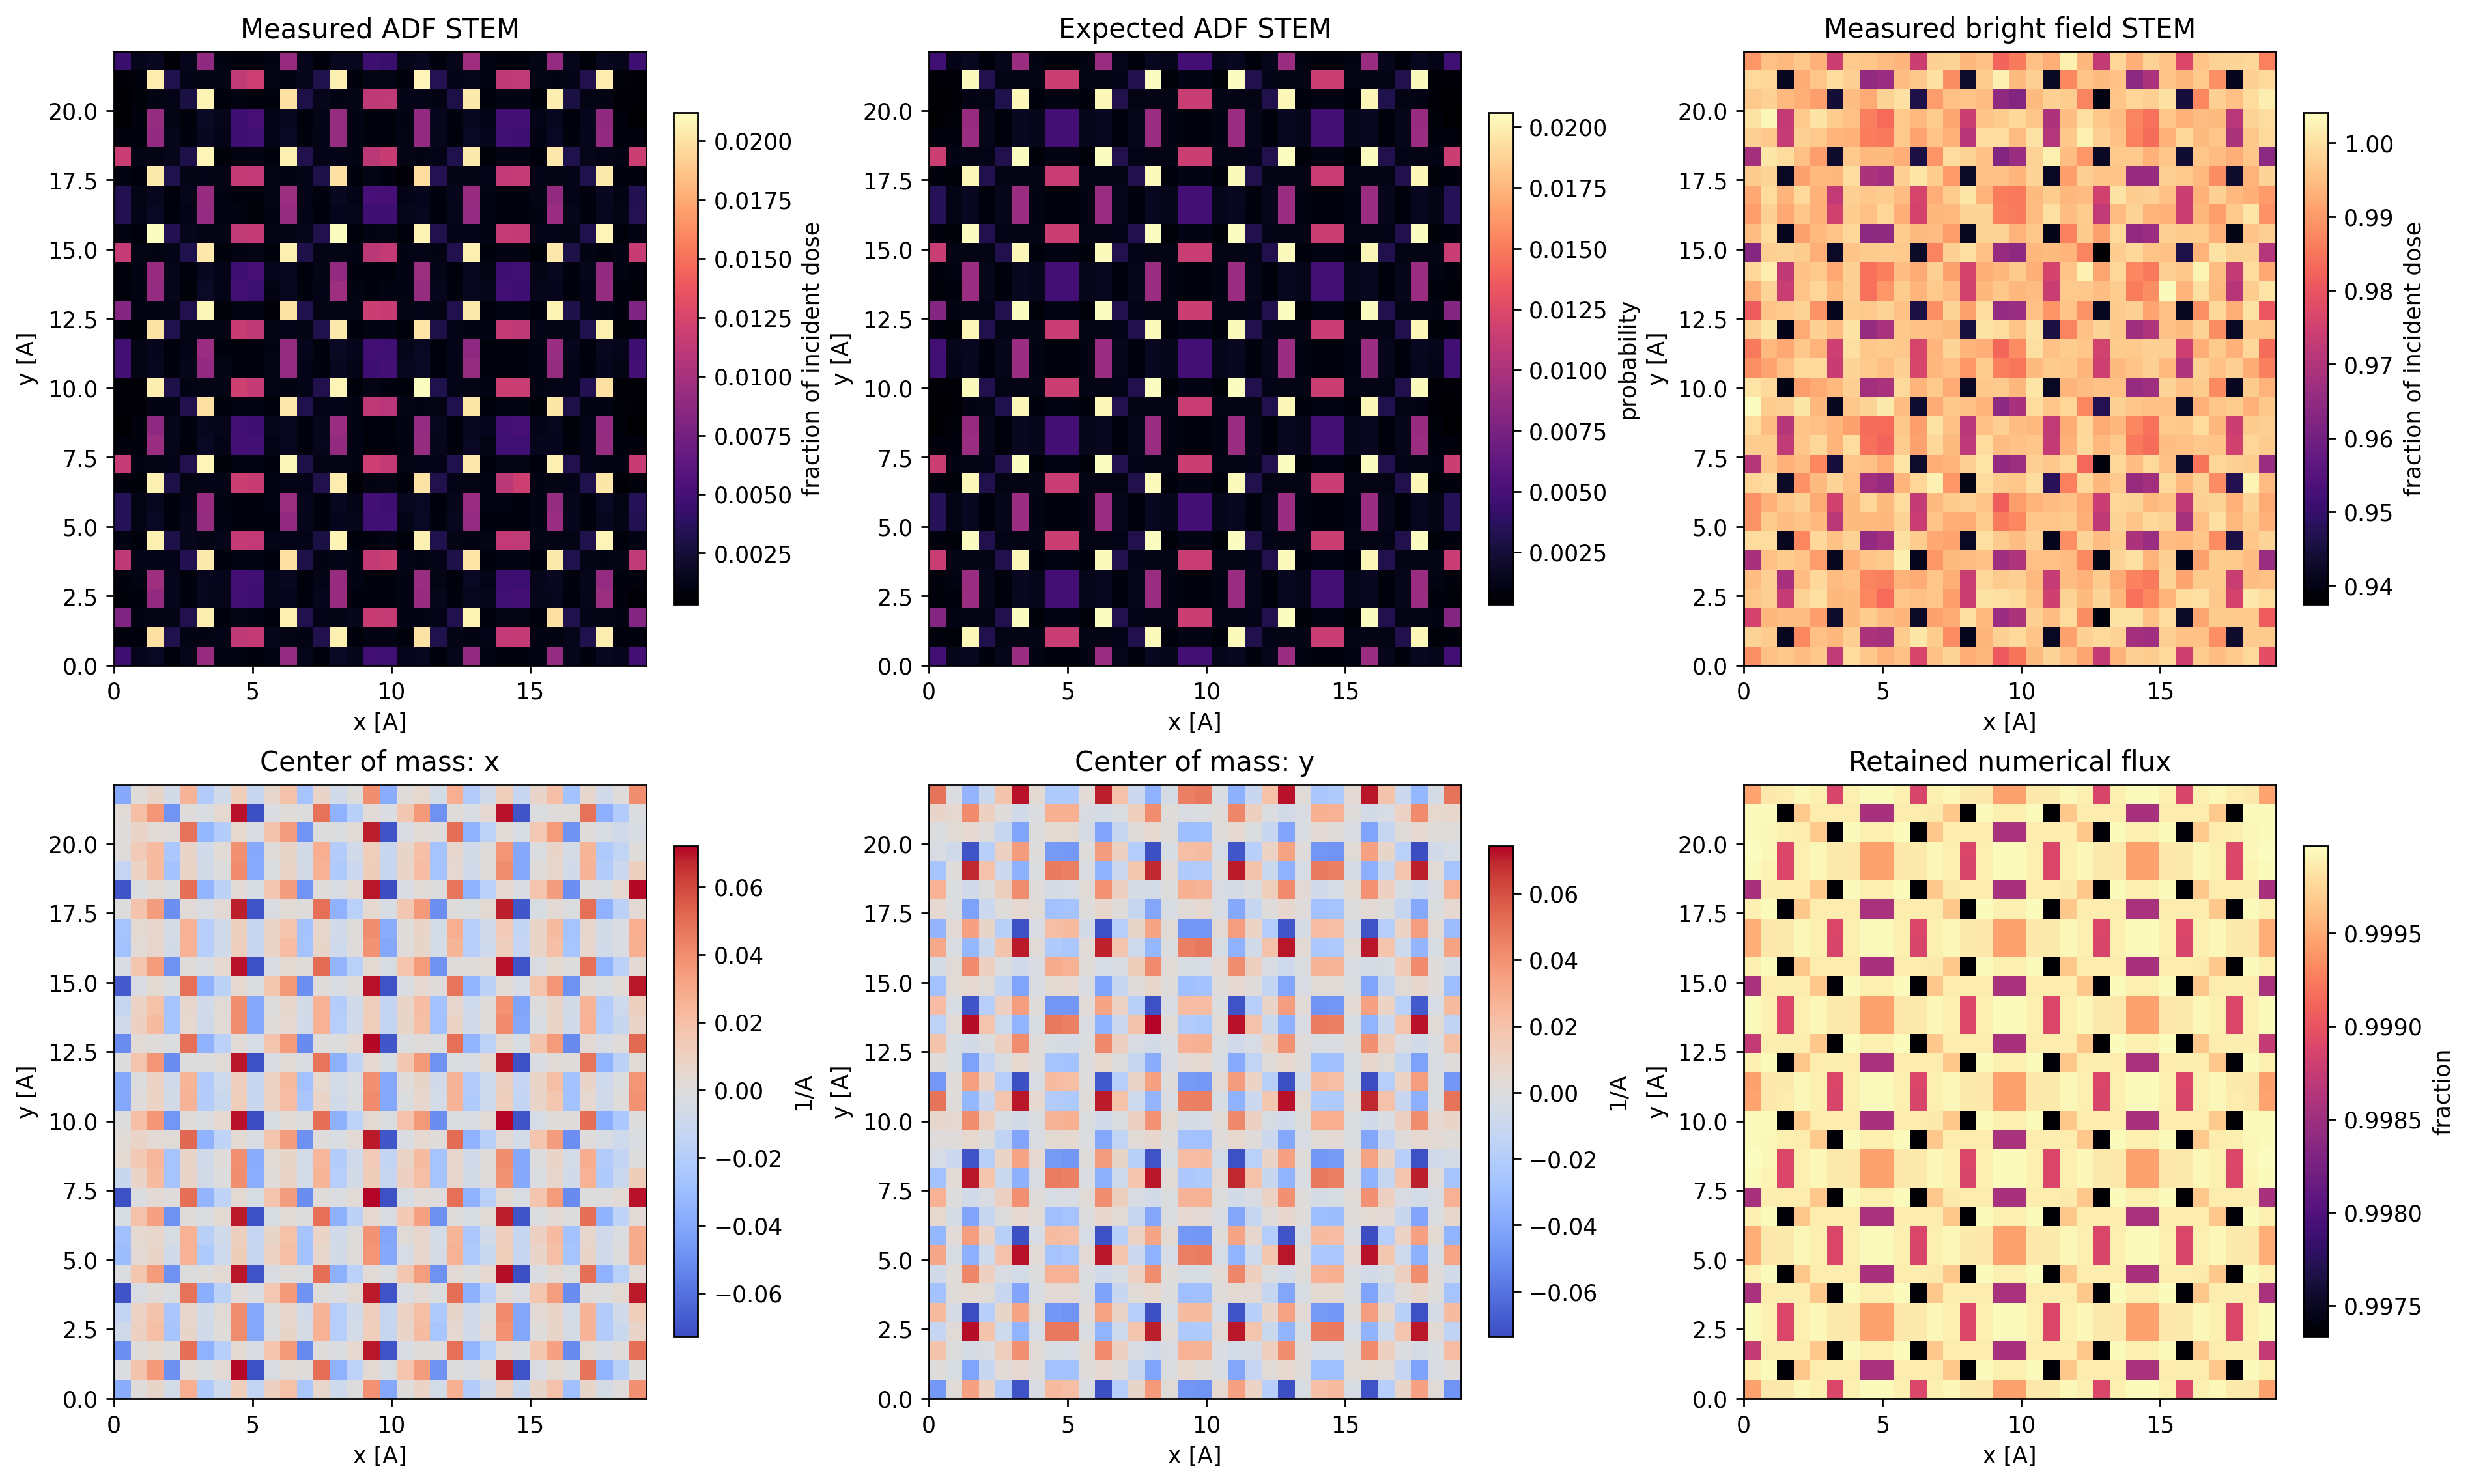

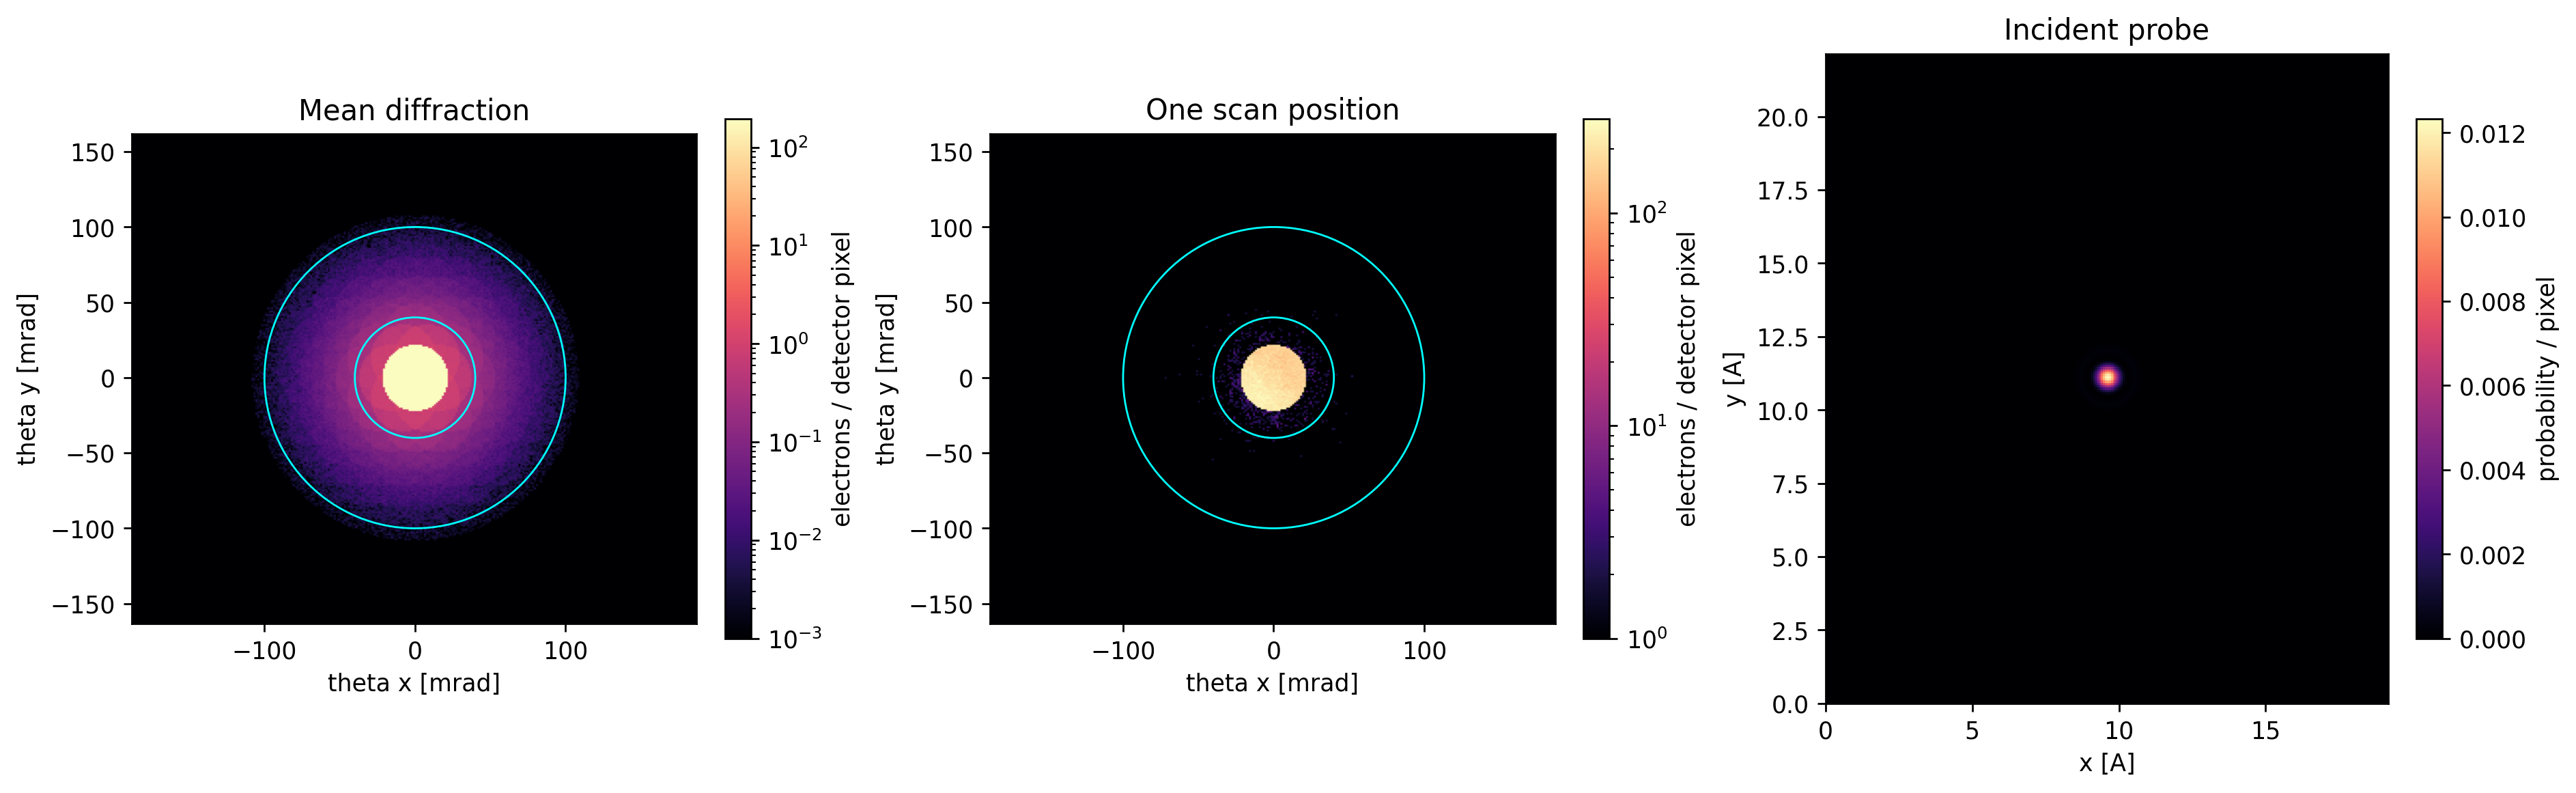

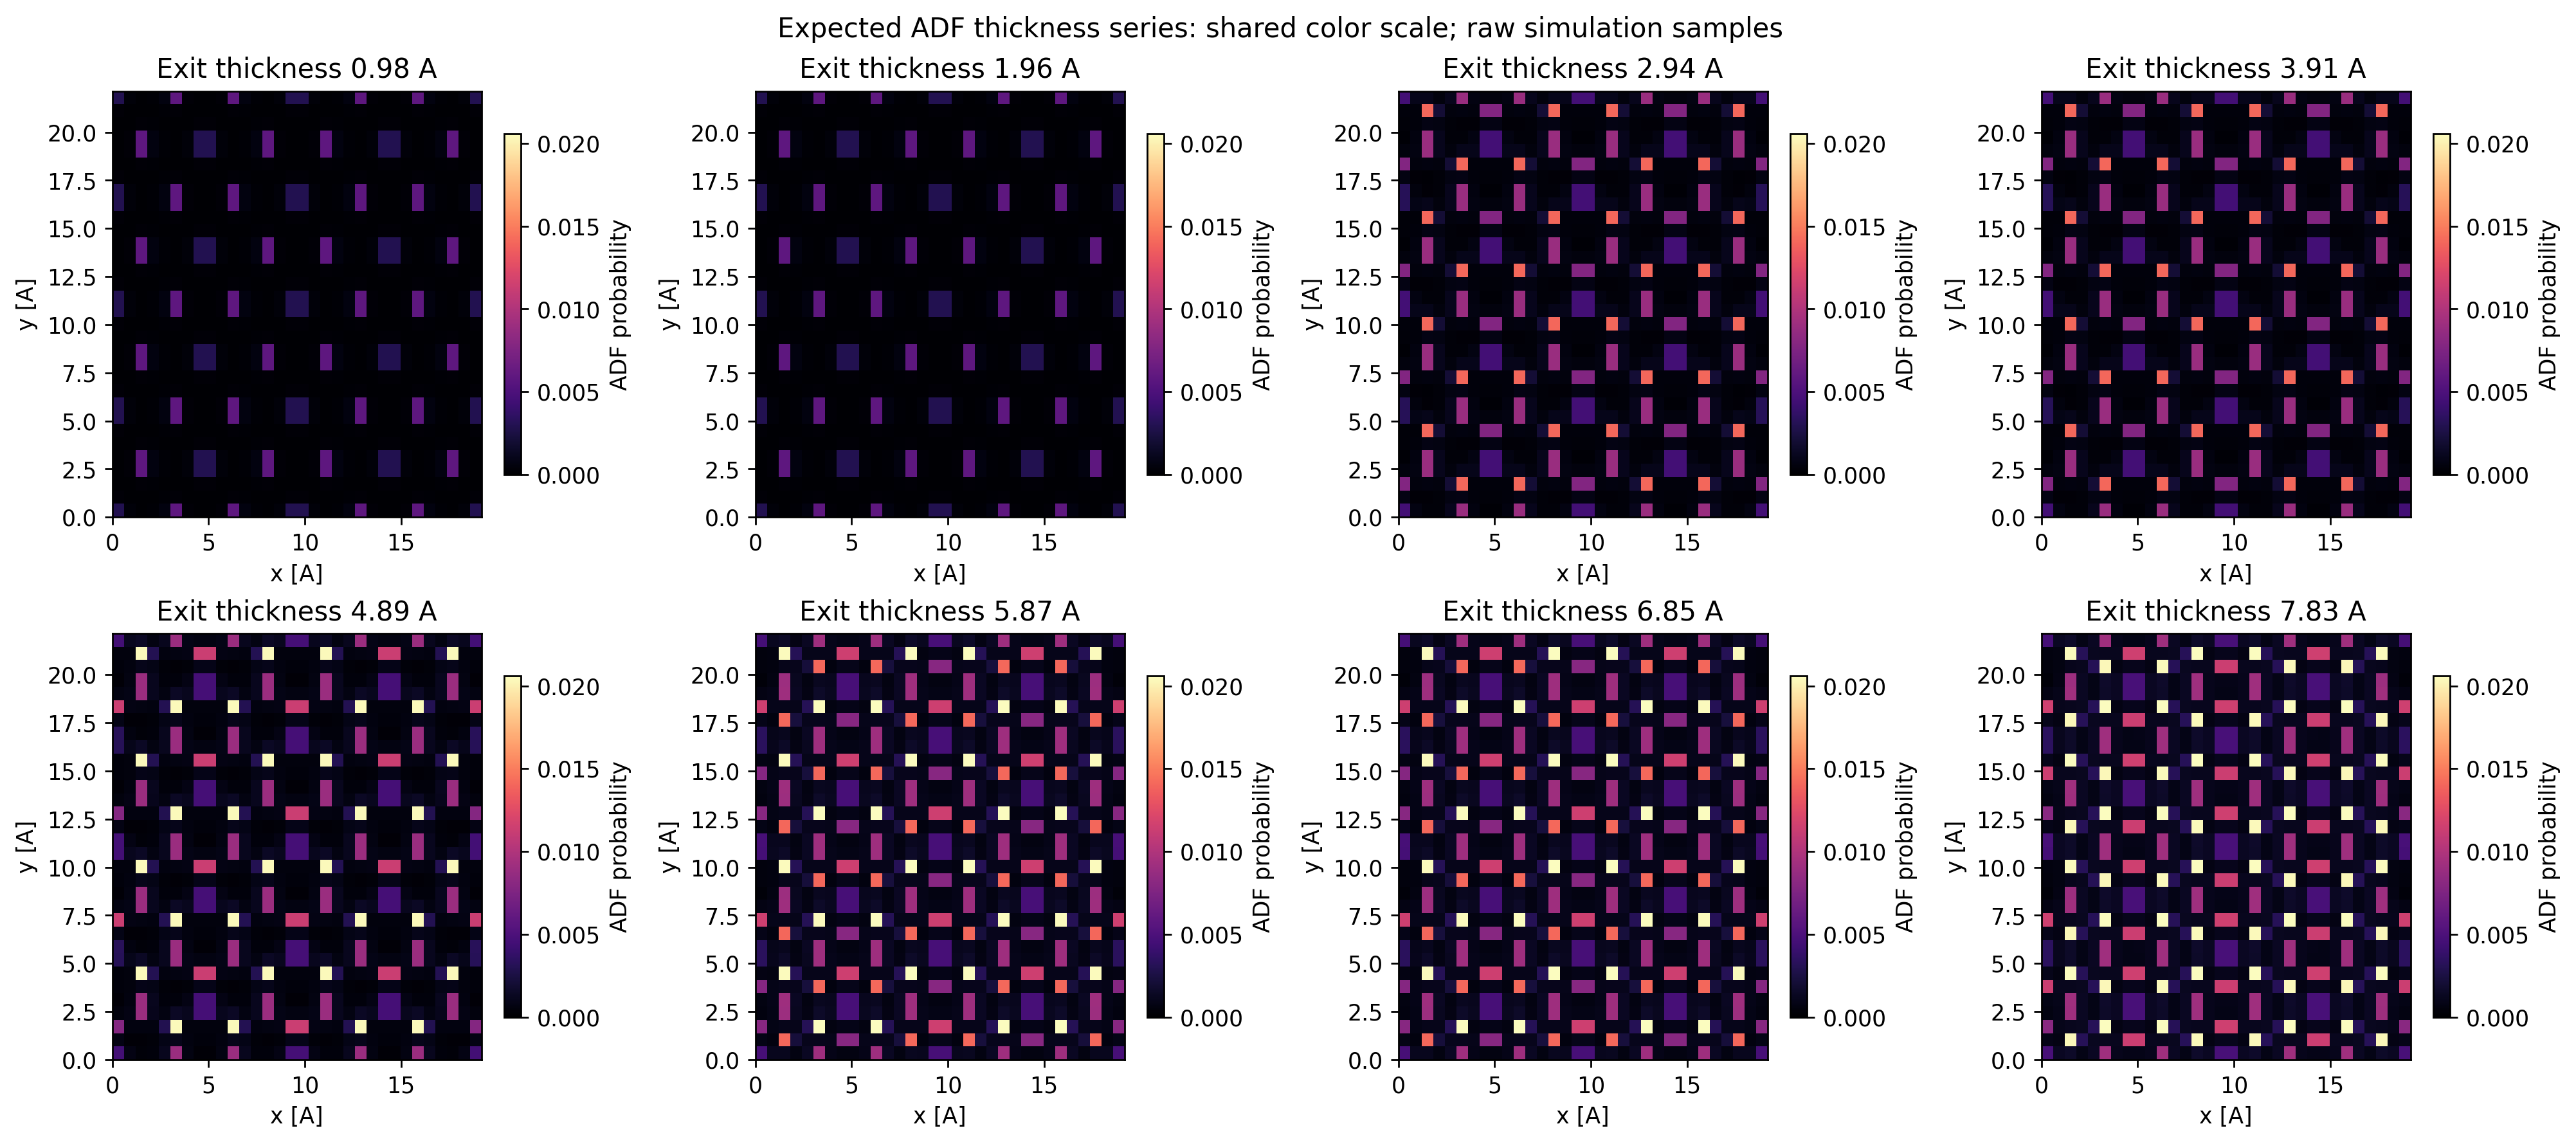

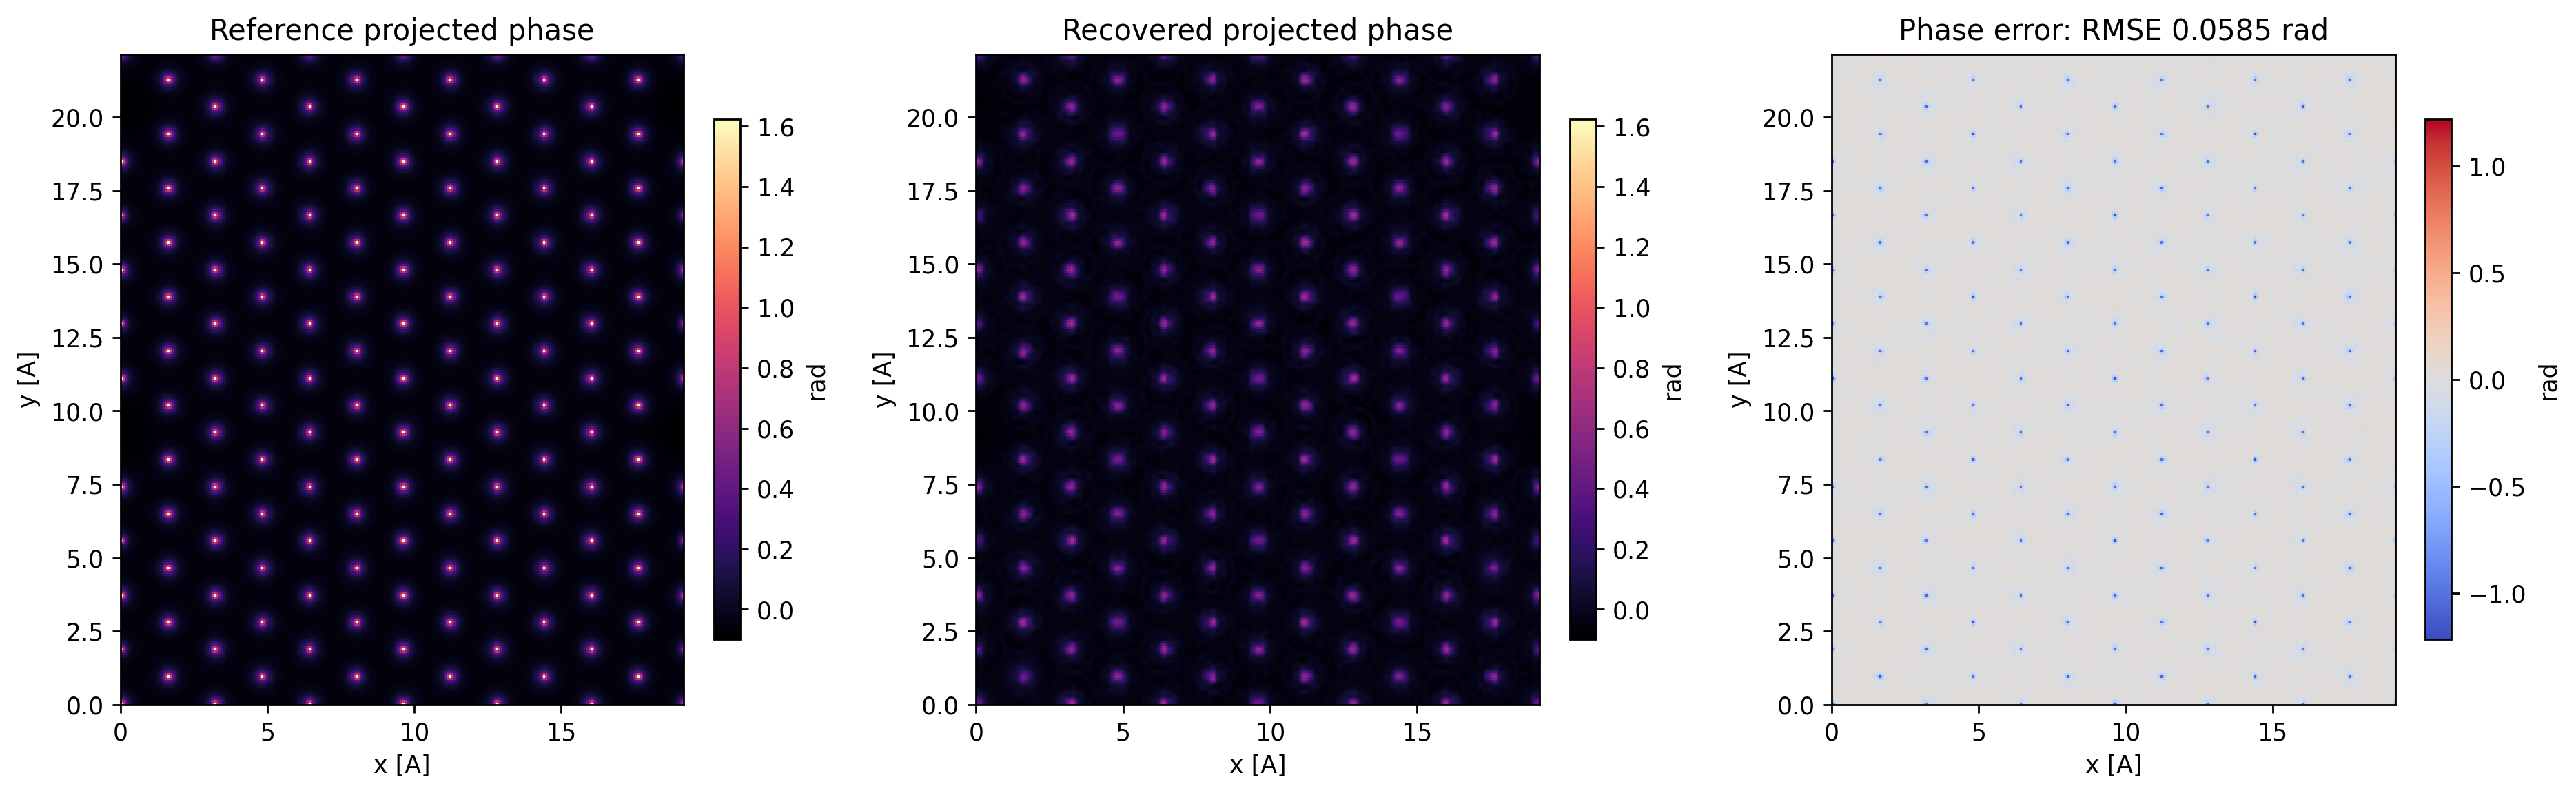

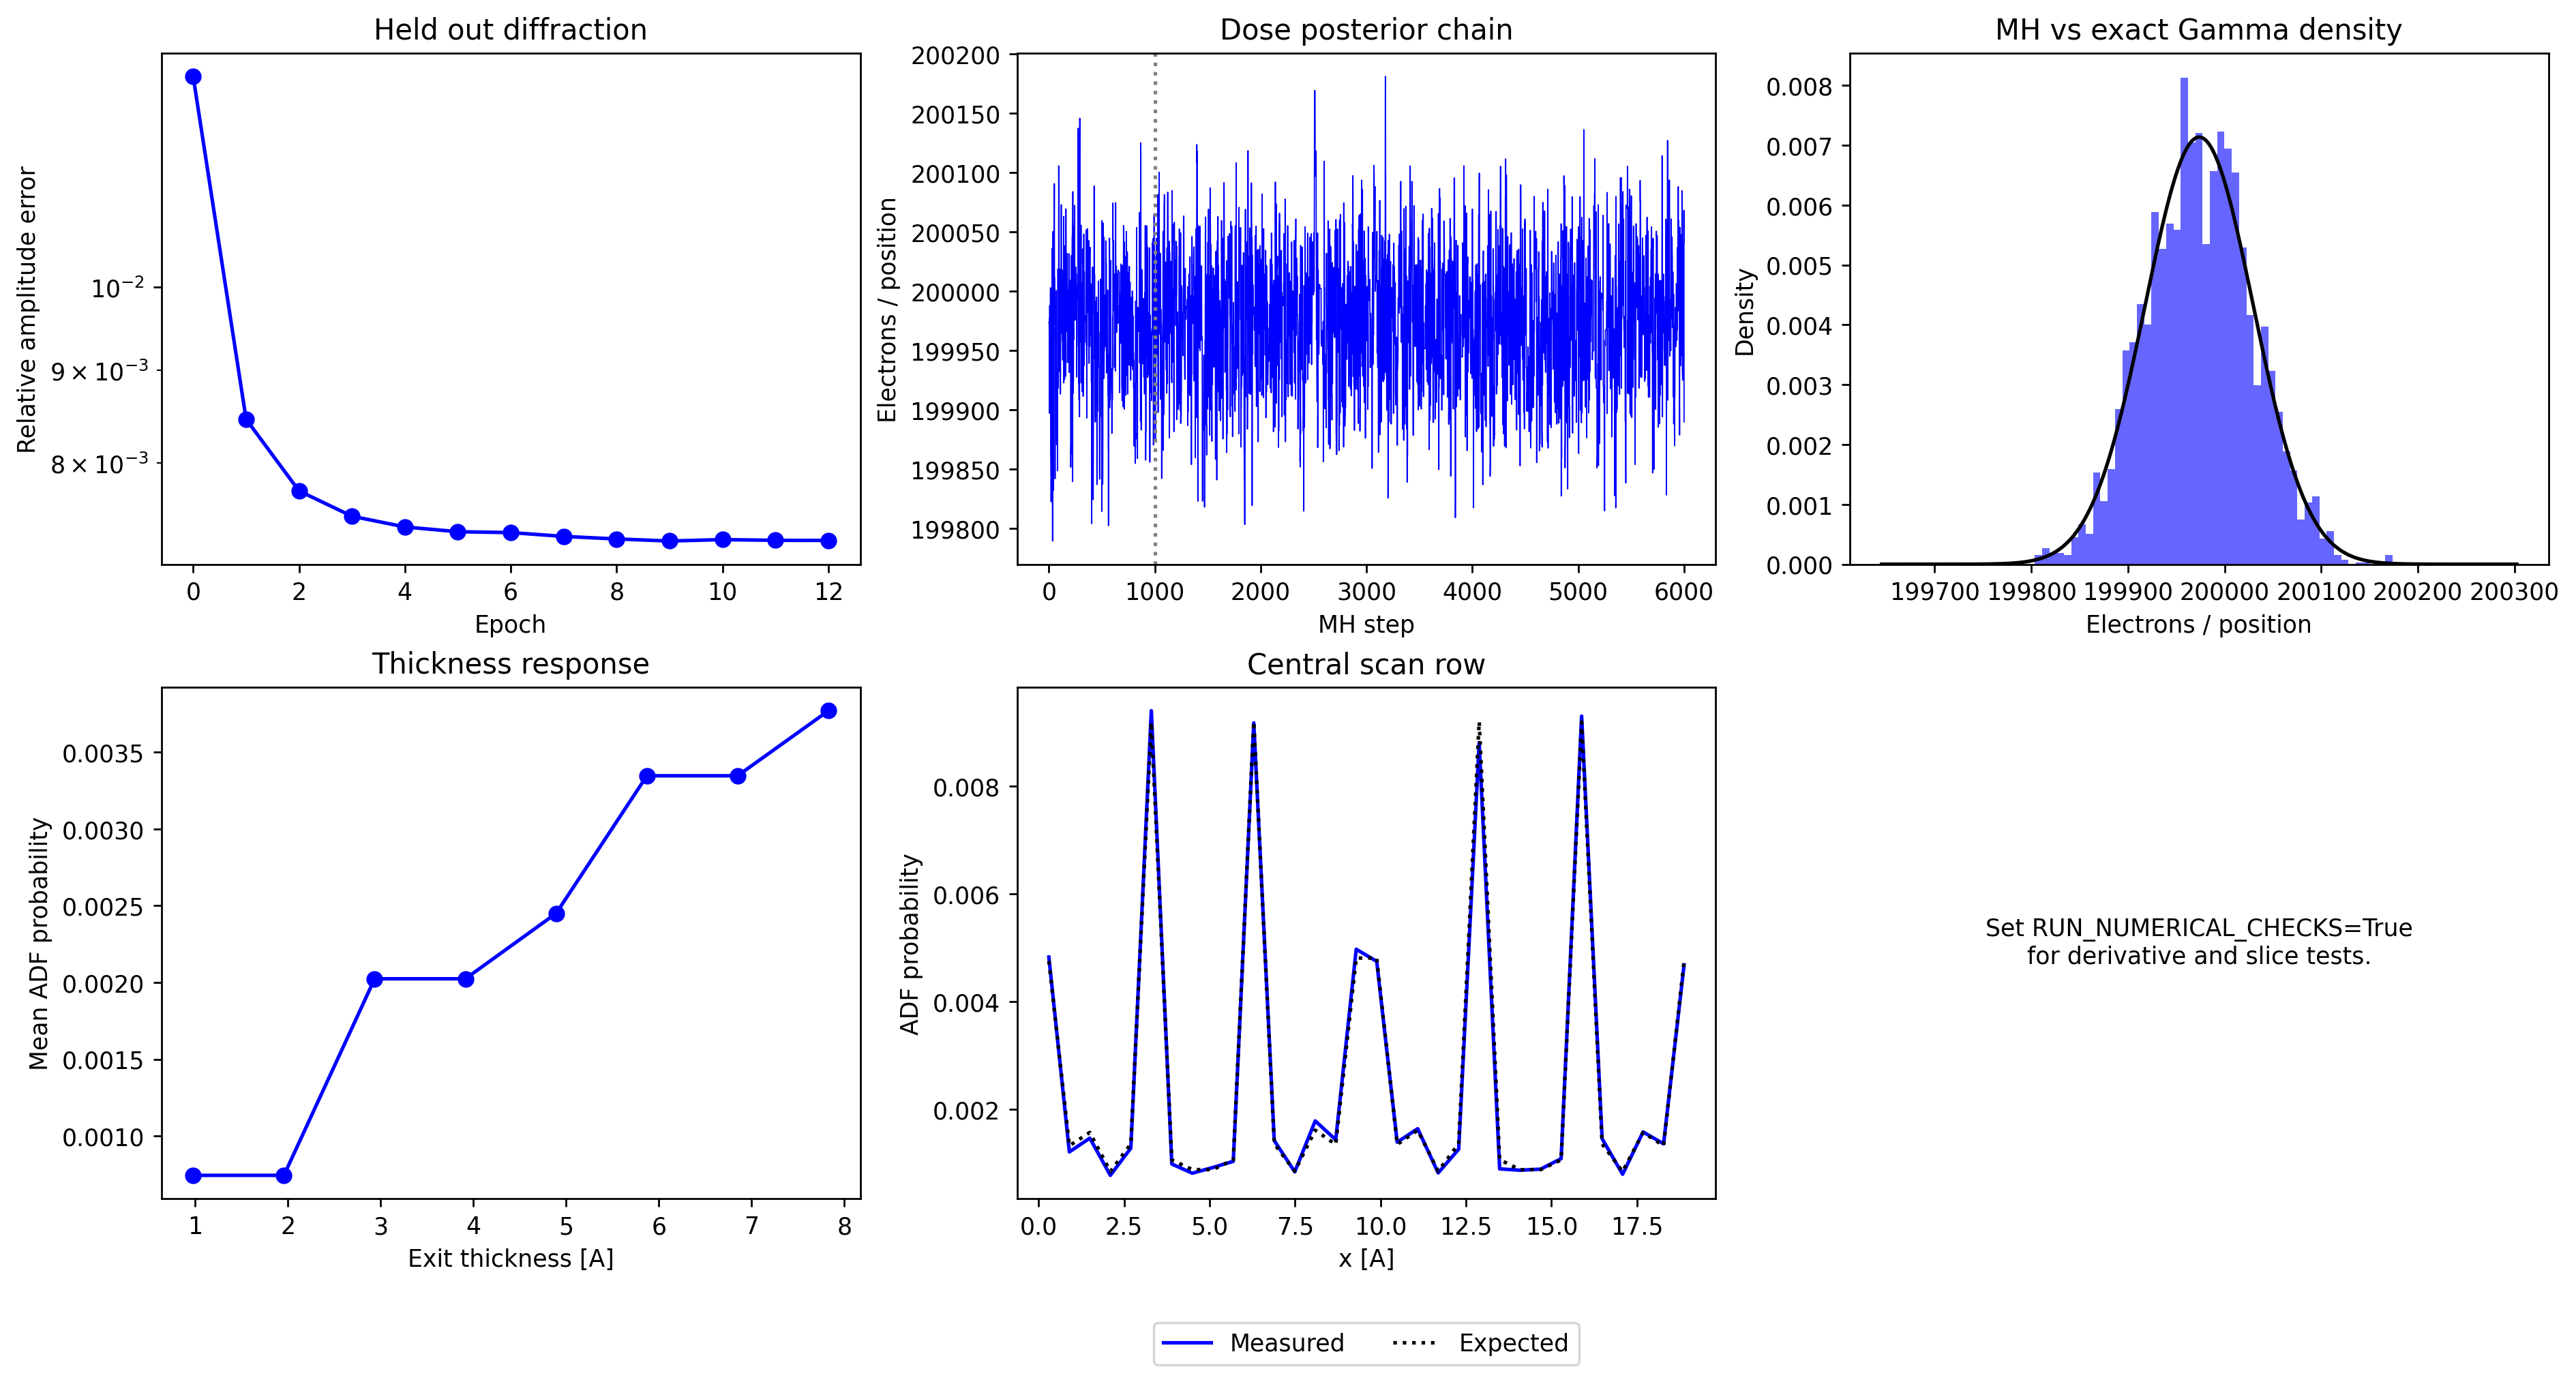

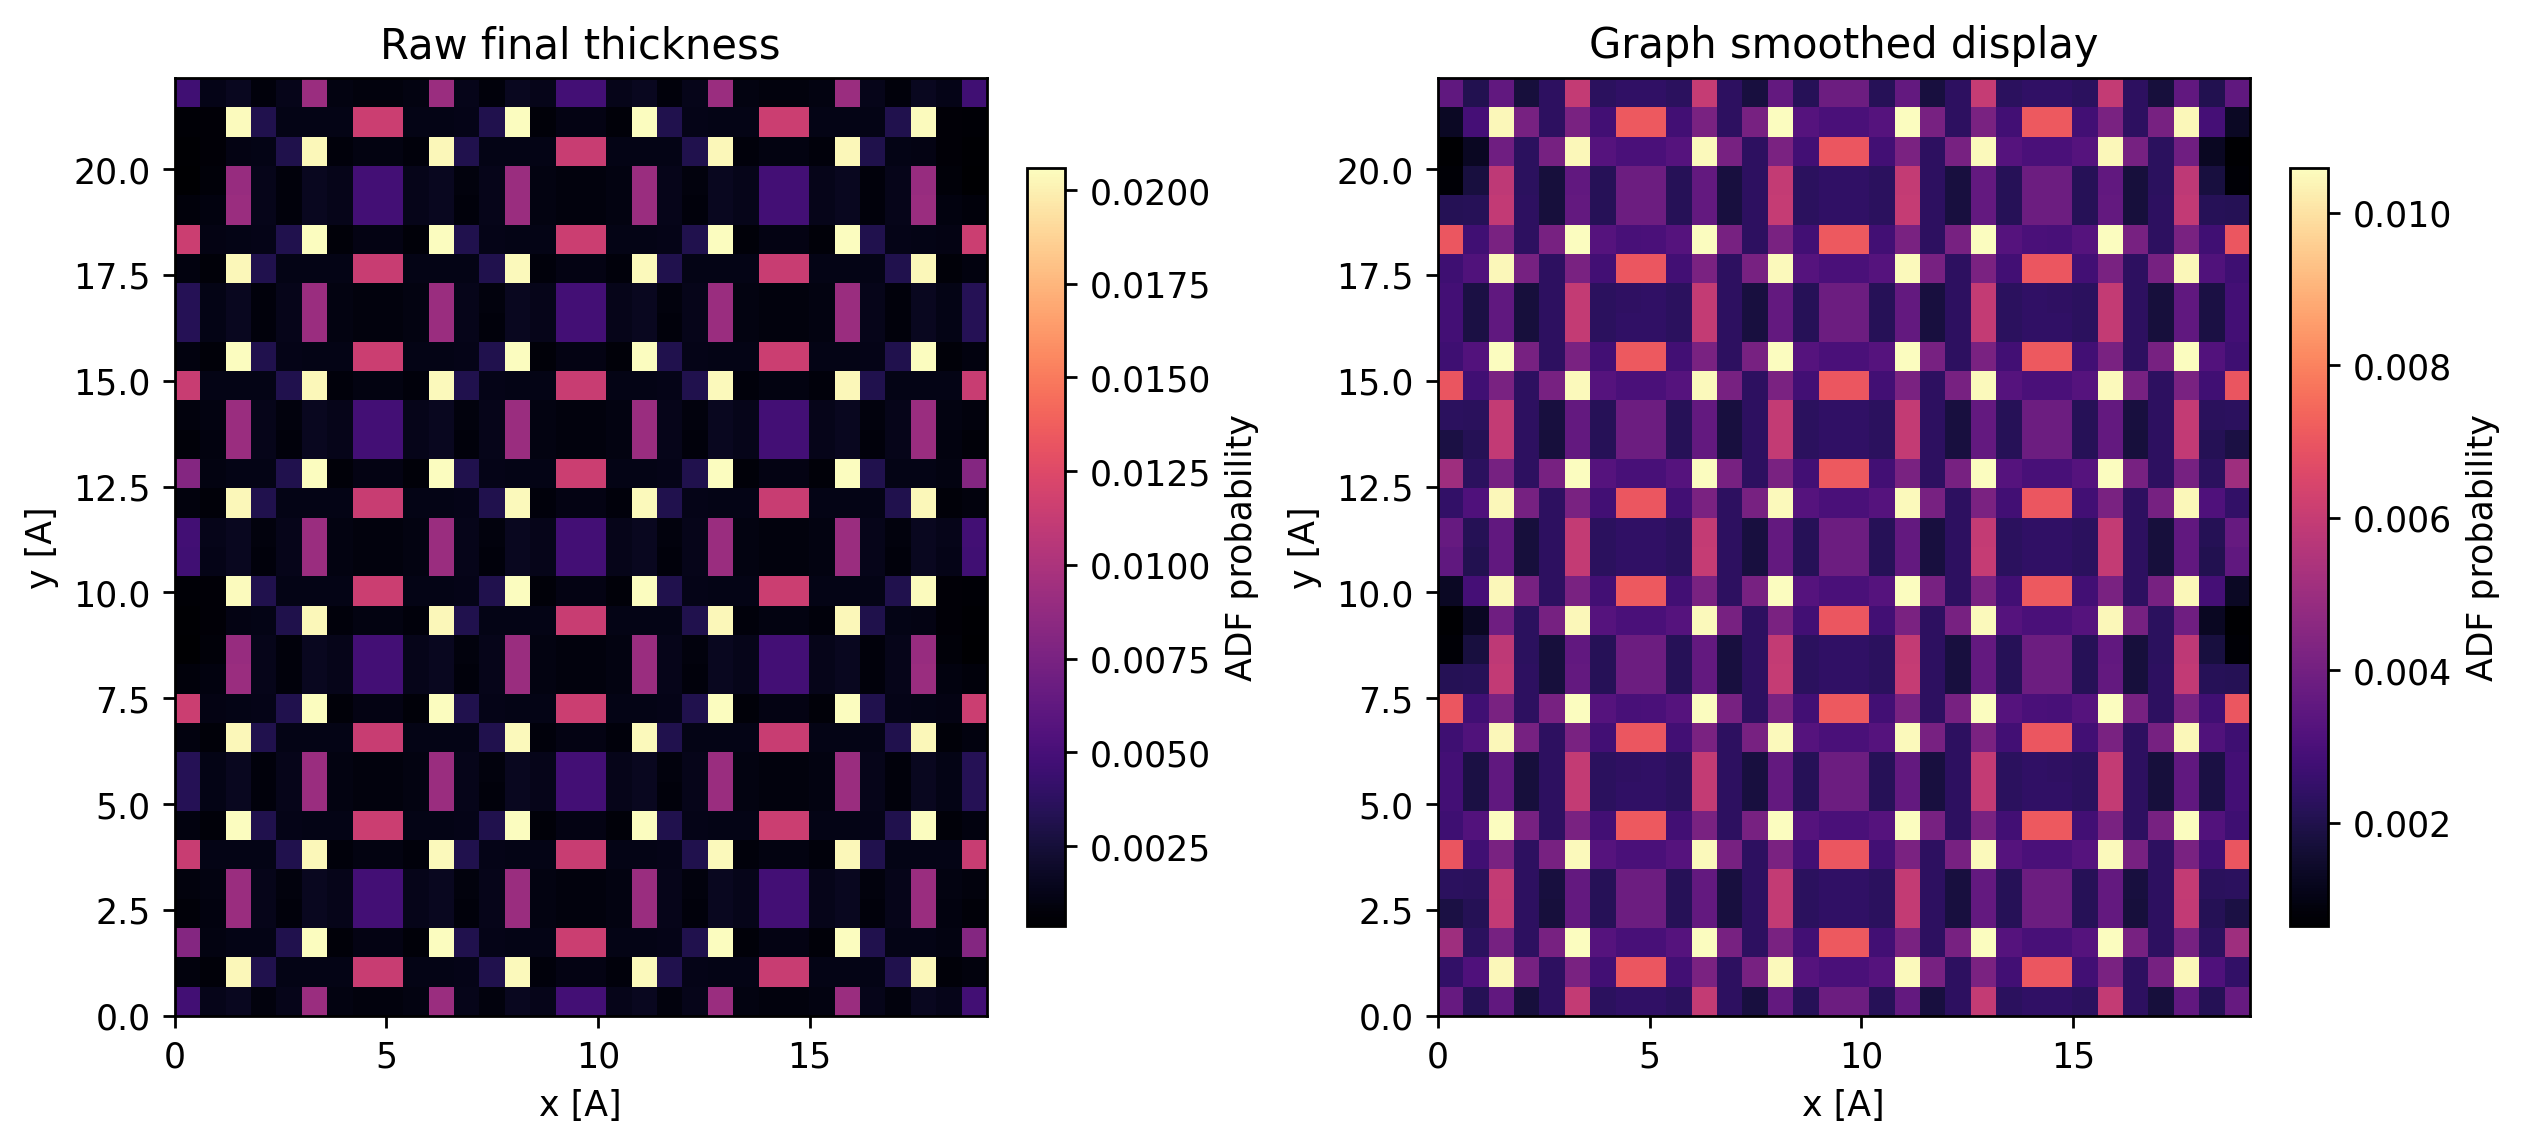

Graph smoothing changes image contrast. Reconstruction always uses raw counts.
Depth dependent phase recovery has limited identifiability from a single beam direction.
A decreasing diffraction error alone cannot certify an accurate 3D atomic reconstruction.


In [6]:
"""Display detector maps, depth series, phase recovery, and numerical diagnostics."""

from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

extent = [0, lengths[0], 0, lengths[1]]
qx_plot = np.fft.fftshift(host(qxx)[0]) * wavelength * 1000
qy_plot = np.fft.fftshift(host(qyy)[:, 0]) * wavelength * 1000
detector_extent = [qx_plot[0], qx_plot[-1], qy_plot[0], qy_plot[-1]]


def heatmap(axis, values, title, units, bounds=extent, cmap="magma", limits=None):
    """Plot one physical image with its own unobstructed color scale."""
    settings = {} if limits is None else {"vmin": limits[0], "vmax": limits[1]}
    artist = axis.imshow(values, origin="lower", extent=bounds, cmap=cmap,
                         interpolation="nearest", **settings)
    axis.set(title=title, xlabel="x [A]", ylabel="y [A]")
    axis.figure.colorbar(artist, ax=axis, shrink=0.8, label=units)
    return artist


fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
heatmap(axes[0, 0], adf, "Measured ADF STEM", "fraction of incident dose")
heatmap(axes[0, 1], expected_adf.reshape(side, side), "Expected ADF STEM", "probability")
heatmap(axes[0, 2], bf, "Measured bright field STEM", "fraction of incident dose")
heatmap(axes[1, 0], com[0], "Center of mass: x", "1/A", cmap="coolwarm")
heatmap(axes[1, 1], com[1], "Center of mass: y", "1/A", cmap="coolwarm")
heatmap(axes[1, 2], flux.reshape(side, side), "Retained numerical flux", "fraction")
plt.show()

mean_pattern = np.fft.fftshift(np.asarray(mean_diffraction))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for axis, pattern, title in zip(
        axes[:2], [mean_pattern, np.fft.fftshift(counts[nscan // 2])],
        ["Mean diffraction", "One scan position"]):
    positive = pattern[pattern > 0]
    low = max(float(positive.min()) if len(positive) else 1e-3, 1e-3)
    high = max(float(pattern.max()), low * 10)
    image = axis.imshow(np.maximum(pattern, low), origin="lower", extent=detector_extent,
                        norm=LogNorm(vmin=low, vmax=high), cmap="magma")
    for radius in ADF_MRAD:
        axis.add_patch(Circle((0, 0), radius, fill=False, color="cyan", linewidth=0.8))
    axis.set(title=title, xlabel="theta x [mrad]", ylabel="theta y [mrad]")
    fig.colorbar(image, ax=axis, shrink=0.8, label="electrons / detector pixel")
center_probe = shifted_probes([[lengths[0] / 2, lengths[1] / 2]], aperture, qxx, qyy)[0]
heatmap(axes[2], host(cp.abs(center_probe)**2), "Incident probe", "probability / pixel")
plt.show()

columns = min(4, nslice)
rows = int(np.ceil(nslice / columns))
fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.5 * rows),
                         squeeze=False, constrained_layout=True)
for index, axis in enumerate(axes.ravel()):
    if index < nslice:
        heatmap(axis, depth_adf[index], f"Exit thickness {exit_depth[index]:.2f} A",
                "ADF probability", limits=(0, float(depth_adf.max())))
    else:
        axis.set_visible(False)
fig.suptitle("Expected ADF thickness series: shared color scale; raw simulation samples")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
phase_limits = (float(min(truth_projected.min(), reconstructed.min())),
                float(max(truth_projected.max(), reconstructed.max())))
heatmap(axes[0], truth_projected, "Reference projected phase", "rad", limits=phase_limits)
heatmap(axes[1], reconstructed, "Recovered projected phase", "rad", limits=phase_limits)
error = reconstructed - truth_projected
heatmap(axes[2], error, f"Phase error: RMSE {phase_rmse:.4f} rad", "rad", cmap="coolwarm",
        limits=(-float(np.abs(error).max()), float(np.abs(error).max())))
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes[0, 0].semilogy(history[:, 0], history[:, 1], "o-", color="blue")
axes[0, 0].set(xlabel="Epoch", ylabel="Relative amplitude error", title="Held out diffraction")
axes[0, 1].plot(np.arange(MH_STEPS), mh_trace, color="blue", linewidth=0.5)
axes[0, 1].axvline(MH_BURN, color="gray", linestyle=":")
axes[0, 1].set(xlabel="MH step", ylabel="Electrons / position", title="Dose posterior chain")
axes[0, 2].hist(mh_trace[MH_BURN:], bins=50, density=True, color="blue", alpha=0.6)
posterior_shape = float(cp.sum(vacuum_counts).item()) + 1
posterior_rate = VACUUM_CALIBRATION_FRAMES + 1e-6
posterior_x = np.linspace(dose_ci[0] - np.diff(dose_ci)[0],
                          dose_ci[1] + np.diff(dose_ci)[0], 300)
axes[0, 2].plot(posterior_x, gamma.pdf(posterior_x, posterior_shape,
                                    scale=1 / posterior_rate), color="black")
axes[0, 2].set(xlabel="Electrons / position", ylabel="Density", title="MH vs exact Gamma density")
axes[1, 0].plot(exit_depth, depth_adf.mean(axis=(1, 2)), "o-", color="blue")
axes[1, 0].set(xlabel="Exit thickness [A]", ylabel="Mean ADF probability", title="Thickness response")
axes[1, 1].plot(scan_x, adf[side // 2], color="blue", label="Measured")
axes[1, 1].plot(scan_x, expected_adf.reshape(side, side)[side // 2], color="black",
                linestyle=":", label="Expected")
axes[1, 1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
axes[1, 1].set(xlabel="x [A]", ylabel="ADF probability", title="Central scan row")
check_labels = []
check_values = []
if np.isfinite(gradient_relative_error):
    check_labels.append("Adjoint")
    check_values.append(gradient_relative_error)
if np.isfinite(slice_relative_error):
    check_labels.append("Half slice")
    check_values.append(slice_relative_error)

if check_values:
    axes[1, 2].bar(check_labels, check_values, color="blue")
    axes[1, 2].set(
        yscale="log",
        ylabel="Relative difference",
        title="Numerical checks",
    )
else:
    axes[1, 2].text(
        0.5,
        0.5,
        "Set RUN_NUMERICAL_CHECKS=True\nfor derivative and slice tests.",
        ha="center",
        va="center",
        transform=axes[1, 2].transAxes,
    )
    axes[1, 2].set_axis_off()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
heatmap(axes[0], depth_adf[-1], "Raw final thickness", "ADF probability")
heatmap(axes[1], smoothed_depth[-1], "Graph smoothed display", "ADF probability")
plt.show()
print("Graph smoothing changes image contrast. Reconstruction always uses raw counts.")
print("Depth dependent phase recovery has limited identifiability from a single beam direction.")
print("A decreasing diffraction error alone cannot certify an accurate 3D atomic reconstruction.")

## 7. Interactive K3D depth, atomic, and phase views

The ADF result is rendered as a volumetric scalar field whose third coordinate is specimen exit thickness. The simulation values keep their physical depth ordering, and only the display field is resampled in the transverse plane for smoother ray casting. A percentile window and gamma transfer control the displayed contrast without altering the stored ADF arrays.

The second view shows Ga and N atoms with the beam parallel to the displayed z axis. The third view renders every reconstructed projected phase sample as a point with an adjustable angstrom per radian display scale. Orbit controls, a hidden grid, antialiasing three, and screenshot scale two are enabled.

The ADF volume uses the K3D volume drawable, which is intended for three dimensional NumPy scalar arrays and supports physical bounds, interpolation, colormaps, and GPU ray casting. [K3D volume API](https://k3d-jupyter.org/reference/factory.volume.html).


In [7]:
"""Initialize the K3D frontend in Google Colab."""

import time

import k3d
import numpy as np
from IPython.display import display

try:
    from google.colab import output

    output.enable_custom_widget_manager()
except ImportError:
    pass

k3d.switch_to_text_protocol()

warmup_view = k3d.plot(
    height=110,
    grid_visible=False,
    background_color=0x000000,
    label_color=0xFFFFFF,
    antialias=1,
)

warmup_view += k3d.points(
    positions=np.asarray([[0.0, 0.0, 0.0]], dtype=np.float32),
    color=0xFFFFFF,
    point_size=0.08,
    shader="3d",
    name="K3D",
    compression_level=0,
)

display(warmup_view)
time.sleep(2.0)

print(f"K3D {k3d.__version__} ready.")


Plot(antialias=1, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], camera_ani…

K3D 2.18.1 ready.


In [8]:
"""Render interactive K3D views of ADF depth, atomic structure, and phase."""

# --- K3D control knobs ---
K3D_ADF_LOW_PERCENTILE = 0.5
K3D_ADF_HIGH_PERCENTILE = 99.5
K3D_ADF_GAMMA = 0.45
K3D_ADF_COLOR_FLOOR = 0.12
K3D_ADF_RELIEF_FRACTION = 0.75
K3D_ADF_POINT_SIZE_A = 0.22
K3D_ADF_OPACITY = 0.95
K3D_ADF_FRAME_PADDING_FRACTION = 0.30
K3D_USE_GRAPH_SMOOTHING = False
K3D_HEIGHT_SCALE_A_PER_RAD = 2.0
K3D_HEIGHT_PX = 650
K3D_ANTIALIAS = 3
K3D_SCREENSHOT_SCALE = 2.0
K3D_COMPRESSION_LEVEL = 0

import time

import numpy as np
import ipywidgets as widgets
import k3d
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from google.colab import output

    output.enable_custom_widget_manager()
except ImportError:
    pass

k3d.switch_to_text_protocol()


def finite_float32(array, name):
    """Return a contiguous finite float32 array."""
    result = np.asarray(array, dtype=np.float32)

    if not np.all(np.isfinite(result)):
        bad_count = result.size - int(np.count_nonzero(np.isfinite(result)))
        raise ValueError(
            f"{name} contains {bad_count:,} nonfinite values."
        )

    return np.ascontiguousarray(result)


def finite_range(array):
    """Return a finite nondegenerate scalar range."""
    values = np.asarray(array, dtype=np.float32)
    minimum = float(np.min(values))
    maximum = float(np.max(values))

    if not np.isfinite(minimum) or not np.isfinite(maximum):
        raise ValueError("Color data contain nonfinite extrema.")

    if maximum <= minimum:
        maximum = minimum + max(abs(minimum), 1.0) * 1e-6

    return [minimum, maximum]


def new_view(axes):
    """Create a dark K3D orbit viewer."""
    view = k3d.plot(
        height=K3D_HEIGHT_PX,
        grid_visible=False,
        grid_auto_fit=True,
        camera_auto_fit=True,
        background_color=0x000000,
        label_color=0xFFFFFF,
        antialias=K3D_ANTIALIAS,
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        axes=axes,
    )
    view.camera_mode = "orbit"
    return view


def magma_colors(values):
    """Map normalized values to packed RGB colors."""
    normalized = np.asarray(values, dtype=np.float32)
    normalized = np.clip(normalized, 0.0, 1.0)
    normalized = (
        K3D_ADF_COLOR_FLOOR
        + (1.0 - K3D_ADF_COLOR_FLOOR) * normalized
    )

    rgb = plt.get_cmap("magma")(normalized)[..., :3]
    rgb = np.rint(rgb * 255.0).astype(np.uint32)

    packed = (
        (rgb[..., 0] << np.uint32(16))
        | (rgb[..., 1] << np.uint32(8))
        | rgb[..., 2]
    )

    return np.ascontiguousarray(
        packed.ravel(),
        dtype=np.uint32,
    )


print("K3D text protocol enabled.")
print(f"K3D version: {k3d.__version__}")


# ---------------------------------------------------------------------------
# ADF exit-depth layer
# ---------------------------------------------------------------------------

input_stack = (
    smoothed_depth
    if K3D_USE_GRAPH_SMOOTHING
    else depth_adf
)

input_stack = finite_float32(
    input_stack,
    "ADF depth stack",
)

exit_depth_array = finite_float32(
    exit_depth,
    "exit depths",
)

if input_stack.ndim != 3:
    raise ValueError(
        "ADF depth stack must have shape "
        "(slice, scan_y, scan_x)."
    )

slice_count, scan_y_count, scan_x_count = input_stack.shape

if slice_count != len(exit_depth_array):
    raise ValueError(
        "ADF slice count and exit-depth count differ."
    )

if scan_y_count != side or scan_x_count != side:
    raise ValueError(
        "ADF scan dimensions do not match side."
    )

if not (
    0.0
    <= K3D_ADF_LOW_PERCENTILE
    < K3D_ADF_HIGH_PERCENTILE
    <= 100.0
):
    raise ValueError(
        "ADF percentile controls must satisfy "
        "0 <= low < high <= 100."
    )

if K3D_ADF_GAMMA <= 0.0:
    raise ValueError("K3D_ADF_GAMMA must be positive.")

low_value, high_value = np.percentile(
    input_stack,
    [
        K3D_ADF_LOW_PERCENTILE,
        K3D_ADF_HIGH_PERCENTILE,
    ],
).astype(np.float32)

if high_value <= low_value:
    high_value = np.float32(
        low_value
        + max(abs(float(low_value)), 1.0) * 1e-6
    )

adf_display = np.clip(
    (input_stack - low_value)
    / (high_value - low_value),
    0.0,
    1.0,
)

adf_display = np.power(
    adf_display,
    np.float32(K3D_ADF_GAMMA),
).astype(np.float32)

positive_spacing = np.diff(exit_depth_array)
positive_spacing = positive_spacing[positive_spacing > 0.0]

if positive_spacing.size:
    layer_spacing = float(np.median(positive_spacing))
else:
    layer_spacing = max(
        float(exit_depth_array[-1]),
        1.0,
    )

relief_scale = max(
    K3D_ADF_RELIEF_FRACTION * layer_spacing,
    0.25,
)

x_coordinates = (
    np.arange(scan_x_count, dtype=np.float32) + 0.5
) * np.float32(lengths[0] / scan_x_count)

y_coordinates = (
    np.arange(scan_y_count, dtype=np.float32) + 0.5
) * np.float32(lengths[1] / scan_y_count)

y_grid, x_grid = np.meshgrid(
    y_coordinates,
    x_coordinates,
    indexing="ij",
)

layer_contrast = np.std(
    adf_display,
    axis=(1, 2),
)

initial_layer = int(
    np.argmax(layer_contrast)
)


def adf_layer_payload(layer_index, relief_fraction=1.0):
    """Return ADF point positions and packed colors for one exit layer."""
    values = np.ascontiguousarray(
        adf_display[layer_index],
        dtype=np.float32,
    )

    positions = np.empty(
        (scan_y_count * scan_x_count, 3),
        dtype=np.float32,
    )

    positions[:, 0] = x_grid.ravel()
    positions[:, 1] = y_grid.ravel()
    positions[:, 2] = (
        np.float32(exit_depth_array[layer_index])
        + values.ravel()
        * np.float32(relief_scale * relief_fraction)
    )

    colors = magma_colors(
        values.ravel()
    )

    return (
        np.ascontiguousarray(
            positions,
            dtype=np.float32,
        ),
        colors,
    )


initial_positions, initial_colors = adf_layer_payload(
    initial_layer
)

adf_view = new_view(
    [
        "x [A]",
        "y [A]",
        "ADF relief at exit depth [A]",
    ]
)

x_min = float(np.min(initial_positions[:, 0]))
x_max = float(np.max(initial_positions[:, 0]))
y_min = float(np.min(initial_positions[:, 1]))
y_max = float(np.max(initial_positions[:, 1]))
z_center = float(np.mean(initial_positions[:, 2]))

x_span = max(x_max - x_min, 1e-6)
y_span = max(y_max - y_min, 1e-6)
x_pad = K3D_ADF_FRAME_PADDING_FRACTION * x_span
y_pad = K3D_ADF_FRAME_PADDING_FRACTION * y_span

frame_positions = np.ascontiguousarray(
    [
        [x_min - x_pad, y_min - y_pad, z_center],
        [x_max + x_pad, y_min - y_pad, z_center],
        [x_min - x_pad, y_max + y_pad, z_center],
        [x_max + x_pad, y_max + y_pad, z_center],
    ],
    dtype=np.float32,
)

frame_points = k3d.points(
    positions=frame_positions,
    color=0x000000,
    point_size=0.001,
    shader="flat",
    opacity=0.01,
    name="ADF frame",
    compression_level=K3D_COMPRESSION_LEVEL,
)

adf_points = k3d.points(
    positions=initial_positions,
    color=0xFF9D00,
    point_size=K3D_ADF_POINT_SIZE_A,
    shader="3d",
    opacity=K3D_ADF_OPACITY,
    name=(
        "ADF exit "
        f"{float(exit_depth_array[initial_layer]):.3f} A"
    ),
    compression_level=K3D_COMPRESSION_LEVEL,
)

adf_view += frame_points
adf_view += adf_points
display(adf_view)
time.sleep(1.0)

adf_points.colors = initial_colors

layer_slider = widgets.IntSlider(
    value=initial_layer,
    min=0,
    max=slice_count - 1,
    step=1,
    description="Exit layer",
    continuous_update=False,
)

relief_slider = widgets.FloatSlider(
    value=1.0,
    min=0.0,
    max=2.5,
    step=0.1,
    description="Relief",
    continuous_update=False,
)

point_slider = widgets.FloatSlider(
    value=K3D_ADF_POINT_SIZE_A,
    min=0.05,
    max=0.60,
    step=0.01,
    description="Point size",
    continuous_update=False,
)

refresh_button = widgets.Button(
    description="Refresh ADF",
    button_style="",
    tooltip="Reload the selected ADF exit layer.",
)


def set_adf_view(change=None):
    """Set the displayed ADF exit layer."""
    layer_index = int(layer_slider.value)

    positions, colors = adf_layer_payload(
        layer_index,
        relief_fraction=float(relief_slider.value),
    )

    adf_points.positions = positions
    adf_points.colors = colors
    adf_points.point_size = float(point_slider.value)
    adf_points.name = (
        "ADF exit "
        f"{float(exit_depth_array[layer_index]):.3f} A"
    )


for control in (
    layer_slider,
    relief_slider,
    point_slider,
):
    control.observe(
        set_adf_view,
        names="value",
    )

refresh_button.on_click(
    set_adf_view
)

display(
    widgets.HBox(
        [
            layer_slider,
            relief_slider,
            point_slider,
            refresh_button,
        ]
    )
)

print(
    f"ADF stack shape: {input_stack.shape}; "
    f"{scan_y_count * scan_x_count:,} points per displayed layer."
)
print(
    f"Initial layer: {initial_layer}; "
    f"exit depth {float(exit_depth_array[initial_layer]):.3f} A."
)
print(
    f"ADF physical range: "
    f"{float(input_stack.min()):.6e} to "
    f"{float(input_stack.max()):.6e}."
)
print(
    f"ADF display window: "
    f"{float(low_value):.6e} to "
    f"{float(high_value):.6e}."
)


# ---------------------------------------------------------------------------
# Atomic structure
# ---------------------------------------------------------------------------

atomic_view = new_view(
    [
        "x [A]",
        "y [A]",
        "z || [111] [A]",
    ]
)

symbols = np.asarray(
    atoms.get_chemical_symbols()
)

atomic_positions = finite_float32(
    atoms.positions,
    "atomic positions",
)

species_settings = {
    "Ga": {
        "color": 0x3388FF,
        "size": 0.50,
    },
    "N": {
        "color": 0xFFCC33,
        "size": 0.30,
    },
}

for symbol, settings in species_settings.items():
    mask = symbols == symbol
    positions = atomic_positions[mask]

    if len(positions) == 0:
        continue

    atomic_view += k3d.points(
        positions=positions,
        color=settings["color"],
        point_size=settings["size"],
        shader="3d",
        name=symbol,
        compression_level=K3D_COMPRESSION_LEVEL,
    )

display(atomic_view)

print(
    f"Atomic objects attached: "
    f"{len(atomic_view.objects)}"
)


# ---------------------------------------------------------------------------
# Reconstructed phase point surface
# ---------------------------------------------------------------------------

phase = finite_float32(
    reconstructed,
    "reconstructed phase",
)

if phase.shape != (GRID, GRID):
    raise ValueError(
        f"Expected reconstructed shape "
        f"({GRID}, {GRID}), got {phase.shape}."
    )

x_phase = (
    np.arange(
        GRID,
        dtype=np.float32,
    )
    * np.float32(lengths[0] / GRID)
)

y_phase = (
    np.arange(
        GRID,
        dtype=np.float32,
    )
    * np.float32(lengths[1] / GRID)
)

py, px = np.meshgrid(
    y_phase,
    x_phase,
    indexing="ij",
)

phase_xyz = np.empty(
    (GRID * GRID, 3),
    dtype=np.float32,
)

phase_xyz[:, 0] = px.ravel()
phase_xyz[:, 1] = py.ravel()
phase_xyz[:, 2] = (
    phase.ravel()
    * np.float32(K3D_HEIGHT_SCALE_A_PER_RAD)
)

phase_attribute = np.ascontiguousarray(
    phase.ravel(),
    dtype=np.float32,
)

phase_view = new_view(
    [
        "x [A]",
        "y [A]",
        "scaled phase height [A]",
    ]
)

phase_points = k3d.points(
    positions=phase_xyz,
    attribute=phase_attribute,
    color_map=k3d.colormaps.matplotlib_color_maps.Magma,
    color_range=finite_range(
        phase_attribute
    ),
    point_size=0.08,
    shader="flat",
    opacity=1.0,
    name="Projected phase [rad]",
    compression_level=K3D_COMPRESSION_LEVEL,
)

phase_view += phase_points
display(phase_view)

print(
    f"Phase cloud: {len(phase_xyz):,} points."
)
print(
    f"Phase height scale: "
    f"{K3D_HEIGHT_SCALE_A_PER_RAD:.3f} A/rad."
)


K3D text protocol enabled.
K3D version: 2.18.1


Plot(antialias=3, axes=['x [A]', 'y [A]', 'ADF relief at exit depth [A]'], axes_helper=1.0, axes_helper_colors…

ADF stack shape: (8, 32, 32); 1,024 points per displayed layer.
Initial layer: 7; exit depth 7.829 A.
ADF physical range: 9.221584e-05 to 2.058830e-02.
ADF display window: 9.221616e-05 to 2.052175e-02.


Plot(antialias=3, axes=['x [A]', 'y [A]', 'z || [111] [A]'], axes_helper=1.0, axes_helper_colors=[16711680, 65…

Atomic objects attached: 2


Plot(antialias=3, axes=['x [A]', 'y [A]', 'scaled phase height [A]'], axes_helper=1.0, axes_helper_colors=[167…

Phase cloud: 82,944 points.
Phase height scale: 2.000 A/rad.


## 8. Optional result export

This cell creates a compact result archive in the Colab working directory. Set `SAVE_4D_DATA = True` near the main controls to include the complete count tensor, which is approximately 0.32 GiB at the initial 32 by 32 scan and 288 by 288 detector settings. Reciprocal arrays retain FFT ordering, with zero frequency at index zero; plotting uses `fftshift`.

Exports include geometry, phases, scan positions, exit thicknesses, expected and measured ADF, reconstruction diagnostics, and calibration information. Download the archive from Colab's Files pane.

In [9]:
"""Export simulation arrays and unit metadata for further analysis."""

def finite_or_none(value):
    """Return a finite scalar or None for disabled diagnostics."""
    return float(value) if np.isfinite(value) else None


metadata = {
    "phase": "zincblende GaN",
    "beam_direction_cubic": [1, 1, 1],
    "energy_eV": ENERGY_EV,
    "lattice_A": LATTICE_A,
    "lengths_A": lengths.tolist(),
    "scan_shape": [side, side],
    "detector_shape": [GRID, GRID],
    "batch": batch,
    "diffraction_axes": [
        "scan_y",
        "scan_x",
        "q_y",
        "q_x",
    ],
    "diffraction_order": "unshifted FFT",
    "potential_unit": "V A",
    "phase_unit": "rad",
    "detector_count_unit": "electrons",
    "adf_unit": "fraction of incident electrons",
    "adf_mrad": ADF_MRAD,
    "dose_estimate": dose_estimate,
    "dose_95_ci": dose_ci.tolist(),
    "phonon_configurations": PHONON_CONFIGS,
    "thermal_rms_A": THERMAL_RMS_A,
    "gradient_relative_error": finite_or_none(
        gradient_relative_error
    ),
    "half_slice_relative_change": finite_or_none(
        slice_relative_error
    ),
    "projected_phase_rmse_rad": phase_rmse,
    "packages": {
        name: version(name)
        for name in [
            "abtem",
            "ase",
            "cupy",
            "numba",
            "numba-cuda",
            "networkx",
            "k3d",
        ]
    },
}

arrays = {
    "metadata_json": np.array(
        json.dumps(
            metadata,
            indent=2,
        )
    ),
    "atom_positions_A": atoms.positions,
    "atomic_numbers": atoms.numbers,
    "scan_positions_A": positions,
    "slice_thickness_A": slice_thickness,
    "exit_depth_A": exit_depth,
    "expected_adf_depth": depth_adf,
    "adf": adf,
    "bf": bf,
    "com_inverse_A": com,
    "reference_phase_slices_rad": host(
        truth_phase
    ),
    "reconstructed_phase_slices_rad": host(
        phase_estimate
    ),
    "history_epoch_error_step_elapsed": history,
    "dose_mh_chain": mh_trace,
    "qx_inverse_A": host(qxx)[0],
    "qy_inverse_A": host(qyy)[:, 0],
}

if SAVE_4D_DATA:
    arrays["counts_4d"] = np.asarray(
        counts
    ).reshape(
        side,
        side,
        GRID,
        GRID,
    )

output_path = Path(
    "GaN_111_STEM_results.npz"
)
np.savez_compressed(
    output_path,
    **arrays,
)

print(
    f"Saved {output_path.resolve()} "
    f"({output_path.stat().st_size / 2**20:.1f} MiB)"
)


Saved /content/GaN_111_STEM_results.npz (3.3 MiB)


## Scope and checks

A reduced NumPy execution of the numerical code was checked during preparation with real ASE geometry and abTEM potentials. The adjoint relative error was about 8.5e-8; held out amplitude error decreased across five reconstruction epochs, and dense versus CSR graph outputs agreed. K3D 2.18.1 object construction and layer visibility callbacks were also exercised. Those checks used a smaller grid, specimen, aperture, and scan than the Colab defaults. CUDA execution speed and browser WebGL rendering require the actual Colab session.

This is an independent atom, paraxial, elastic multislice demonstration with ideal detector pixels. Experimental interpretation would require calibrated thickness, tilt, probe aberrations, coherence, detector response, dose, and thermal motion. Bonding charge, inelastic losses, damage, scan drift, and detector point spread require additional modeling. A single beam orientation also limits the identifiability of a three dimensional reconstruction.

## References and API documentation

* [GaN structural parameters, Ioffe Institute](https://www.ioffe.ru/SVA/NSM/Semicond/GaN/basic.html), including zincblende lattice parameter and separate wurtzite structure.
* [ASE construction documentation](https://docs.ase-lib.org/ase/build/build.html), for crystal and supercell construction.
* [abTEM potential walkthrough](https://abtem.readthedocs.io/en/main/user_guide/walkthrough/potentials.html), for independent atom potentials and projected slice conventions.
* [abTEM Potential API](https://abtem.readthedocs.io/en/latest/reference/api/_autosummary/abtem.potentials.iam.Potential.html), for the CPU potential builder used here.
* [abTEM multislice walkthrough](https://abtem.readthedocs.io/en/main/user_guide/walkthrough/multislice.html), for wave propagation and diffraction simulation.
* [K3D points API](https://k3d-jupyter.org/reference/factory.points.html), for point attributes, opacity, and color mapping.

The implemented optimizer is a custom adjoint multislice phase solver. Its executable directional derivative test documents the derivative used by this notebook.